In [1]:
import pandas as pd
import yaml
import os
import openpyxl
import pygwalker as pyg
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
import sys
from pathlib import Path
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

In [2]:
# To add project files
# Keeps going up project structure until it gets to the root.
# Per https://chatgpt.com/g/g-p-69399a7fcc808191b337d3fac695447c-afolu-flux-model/c/69a5ff07-91e0-8329-88d1-cf2ea6c159c2
project_root = Path().resolve()
while project_root.name != "AFOLU_GHG_flux_model":
    project_root = project_root.parent

sys.path.append(str(project_root))

from src.utilities import constants_and_names as cn

In [3]:
# Assigns climate domain column
def assign_climate_domain(df):

    cont_eco = df["continent_ecozone"]

    df["climate_domain"] = np.select(
        [
            cont_eco.str.contains("boreal", case=False, na=False) | cont_eco.str.contains("polar", case=False, na=False),
            cont_eco.str.contains("temperate", case=False, na=False),
            cont_eco.str.contains("tropical", case=False, na=False) | cont_eco.str.contains("subtropical", case=False, na=False),
        ],
        [
            "Boreal",
            "Temperate",
            "Subtropical/tropical",
        ],
        default="Other"
    )

    return df

In [4]:
# Fills in the intervening years of the multi-year intervals for soil data.
# Basically, duplicates values from end-of-interval years for all the preceding years in the interval,
# but only for that row's own nominal interval. Missing intervals stay blank.
# Per https://chatgpt.com/g/g-p-69399a7fcc808191b337d3fac695447c-afolu-flux-model/c/69c2fe30-7004-8328-9f6d-1c231ba04e20
def fill_in_soil_years(df, series_cols):

    # For summing within year
    group_cols = series_cols + ["year"]

    # Aggregate first
    df = (
        df
        .groupby(group_cols, dropna=False, as_index=False)
        .agg({
            "flux_Mg_CO2e_yr": "sum",
            "area_ha": "sum"
        })
    )

    # Sort by timeseries + year
    df = df.sort_values(series_cols + ["year"]).reset_index(drop=True)

    year_vals = df["year"].astype(int)

    # Maximum (final) year in the dataset
    last_year = year_vals.max()

    # Nominal interval length for each endpoint year:
    # - years divisible by 5 -> 5-year interval
    # - final year in dataset -> interval from 2021 to last_year
    # - everything else defaults to 1 year unless you add more rules
    interval_len = np.where(
        year_vals.eq(last_year),
        last_year - 2021 + 1,
        np.where(year_vals.mod(5).eq(0), 5, 1)
    )

    # Start year comes only from the row's own nominal interval,
    # not from the previous observed year.
    start_year = (year_vals - interval_len + 1).astype(int).to_numpy()
    end_year = year_vals.to_numpy()

    # Number of repetitions for each interval
    n_rep = end_year - start_year + 1

    # Duplicate rows
    expanded = df.loc[df.index.repeat(n_rep)].copy()

    # Assign correct years
    expanded["year"] = np.concatenate([
        np.arange(s, e + 1) for s, e in zip(start_year, end_year)
    ])

    expanded = expanded.reset_index(drop=True)

    # If the source data ends before the end of the vegetation timeseries, extendyears through 2024 to match vegetation timeseries
    if last_year < cn.years_annual[-1]:
        rows_2022 = expanded[expanded["year"] == 2022].copy()

        rows_2023 = rows_2022.copy()
        rows_2023["year"] = 2023

        rows_2024 = rows_2022.copy()
        rows_2024["year"] = 2024

        expanded = pd.concat([expanded, rows_2023, rows_2024], ignore_index=True)
        expanded = expanded.sort_values(series_cols + ["year"]).reset_index(drop=True)

    return expanded

In [37]:
# Context columns that define a unique timeseries. Does not include year.
series_cols = [
    "analysis_layer",
    "adm0", "country_name", "region",
    "land_state_node", "land_state", "land_state_meaning",
    "WDPA", "WDPA_type",
    "cont_eco", "continent", "continent_ecozone", "climate_domain",
    "Landmark",
    "starting_composite_primary_forest",
    "tile_id",
    "land_state_broad_class",
    "land_state_detailed_class",
    "WDPA_high_protection",
    "tall_veg_type",
    "LULUCF_component"
]

# Contextual columns for grouping in export csvs. Includes year.
export_csv_group_cols = [
    "analysis_layer",
    "adm0", "country_name", "region",
    # "land_state_node", "land_state", "land_state_meaning",
    # "WDPA", "WDPA_type",
    "cont_eco", "continent", "continent_ecozone", "climate_domain",
    # "Landmark",
    # "starting_composite_primary_forest",
    "year",
    # "tile_id",
    "land_state_broad_class",
    "land_state_detailed_class",
    # "WDPA_high_protection",
    "tall_veg_type",
    "LULUCF_component"
]

### Input table paths

In [6]:
# Vegetation zonal stats output
veg_zonal_stats_folder = f'/mnt/c/GIS/AFOLU_flux_model/LULUCF/zonal_statistics/vegetation_v{cn.veg_model_version_underscore}_standard_global__20260224/'
veg_parquet_name = f'veg_model_zonal_stats_v{cn.veg_model_version_underscore}_20260224_19_21_07.parquet'

In [7]:
# SOC (including mineral soil) zonal stats output
SOC_zonal_stats_folder = f'/mnt/c/GIS/AFOLU_flux_model/LULUCF/zonal_statistics/SOC_v{cn.SOC_model_version_underscore}_standard_global__20260323/'
SOC_parquet_name = f'SOC_zonal_stats_v{cn.SOC_model_version_underscore}_20260323_15_05_52.parquet'

In [8]:
# Organic soil zonal stats output
org_soil_zonal_stats_folder = f'/mnt/c/GIS/AFOLU_flux_model/LULUCF/zonal_statistics/organic_soil_v{cn.organic_soil_model_version_underscore}_standard_global__20251118/'
org_soil_csv_name = 'by_country_climate_component_period__from_Erin_Glen_via_Slack_20260324.csv'

In [9]:
# Output only
LULUCF_zonal_stats_folder = f'/mnt/c/GIS/AFOLU_flux_model/LULUCF/zonal_statistics/LULUCF__veg_105__SOC_100__organicsoil_097__20260323/'  # Date is the latest date of the three inputs, not the current date

### Full dataframes with basic standardization of organic soil and SOC density to vegetation df

In [10]:
%%time

# Reads vegetation zonal stats parquet table
veg_df_raw = pd.read_parquet(f'{veg_zonal_stats_folder}{veg_parquet_name}')

# Renames value column with units
veg_df_raw.rename(columns={'value': 'flux_Mg_CO2e_yr'}, inplace=True)

# Renames some countries with long names
veg_df_raw["country_name"] = veg_df_raw["country_name"].replace({         
    "United Kingdom of Great Britain and Northern Ireland": "United Kingdom",
    "Russian Federation": "Russia",
    "Democratic Republic of the Congo": "DR Congo",
    "United States of America (the)": "USA"
})

# Create new column that separates out high protection status
# https://chatgpt.com/g/g-p-69399a7fcc808191b337d3fac695447c-afolu-flux-model/c/69aee45e-ce6c-8325-b1d0-a6c6b0e7ae2e
veg_df_raw["WDPA_high_protection"] = "Other protection status"
veg_df_raw.loc[veg_df_raw["WDPA_type"] == "NA", "WDPA_high_protection"] = "Not protected"
veg_df_raw.loc[veg_df_raw["WDPA_type"].isin(["Cateogry Ia", "Category Ib", "Category II", "Category III"]), "WDPA_high_protection"] = "High protection"

# Assigns tall vegetation type
state_node_df = pd.read_excel(cn.state_node_lookup_table_local, sheet_name=cn.sheet)
veg_df_raw = veg_df_raw.merge(state_node_df[['land_state', 'tall_veg_type']],  # Merge tall_veg_type field from state_node_df
          left_on='land_state_node', right_on='land_state',
          how='left')

# Adds climate domain column
veg_df_raw = assign_climate_domain(veg_df_raw)

# Prepends veg to rows to clarify their scope
veg_df_raw["analysis_layer"] = "veg_" + veg_df_raw["analysis_layer"]

# New column to specify this is vegetation, as opposed to organic or mineral soil (for combined LULUCF table)
veg_df_raw["LULUCF_component"] = "vegetation"

print(f"Rows in df: {len(veg_df_raw)}")
veg_df_raw.head(6)

Rows in df: 27999047
CPU times: user 1min 25s, sys: 27 s, total: 1min 52s
Wall time: 1min 22s


,analysis_layer,adm0,land_state_node,WDPA,cont_eco,Landmark,starting_composite_primary_forest,year,flux_Mg_CO2e_yr,tile_id,...,region,continent,continent_ecozone,WDPA_type,density__Mg_ha,WDPA_high_protection,land_state,tall_veg_type,climate_domain,LULUCF_component
0,veg_gross_emissions__AGC__MgCO2,NA,12100000,0,1020,0,0,2016,8.630256,00N_000E,...,no_country,Africa,Tropical rainforest,NA,7.012017,Not protected,12100000,mangrove,Subtropical/tropical,vegetation
1,veg_gross_emissions__AGC__MgCO2,NA,12100000,0,1020,0,0,2017,12.399805,00N_000E,...,no_country,Africa,Tropical rainforest,NA,53.733429,Not protected,12100000,mangrove,Subtropical/tropical,vegetation
2,veg_gross_emissions__AGC__MgCO2,NA,12100000,0,1020,0,1,2016,58.504814,00N_000E,...,no_country,Africa,Tropical rainforest,NA,30.423250,Not protected,12100000,mangrove,Subtropical/tropical,vegetation
3,veg_gross_emissions__AGC__MgCO2,NA,12100000,0,1020,0,1,2017,16.906231,00N_000E,...,no_country,Africa,Tropical rainforest,NA,27.472500,Not protected,12100000,mangrove,Subtropical/tropical,vegetation
4,veg_gross_emissions__AGC__MgCO2,NA,12100000,11,1020,0,0,2016,1.523145,00N_000E,...,no_country,Africa,Tropical rainforest,Not Reported,0.990007,Other protection status,12100000,mangrove,Subtropical/tropical,vegetation
5,veg_gross_emissions__AGC__MgCO2,NA,12100000,11,1020,0,0,2017,6.321051,00N_000E,...,no_country,Africa,Tropical rainforest,Not Reported,41.084923,Other protection status,12100000,mangrove,Subtropical/tropical,vegetation


In [11]:
%%time

# Reads SOC zonal stats parquet table
SOC_df_raw = pd.read_parquet(f'{SOC_zonal_stats_folder}{SOC_parquet_name}')

# Renames value column with units
SOC_df_raw.rename(columns={'value': 'flux_Mg_CO2e_yr'}, inplace=True)

# Renames some countries with long names
SOC_df_raw["country_name"] = SOC_df_raw["country_name"].replace({         
    "United Kingdom of Great Britain and Northern Ireland": "United Kingdom",
    "Russian Federation": "Russia",
    "Democratic Republic of the Congo": "DR Congo",
    "United States of America (the)": "USA"
})

# Identifies change layers only to do some unit conversions
mask = SOC_df_raw["analysis_layer"].str.contains("change", na=False)

# Changes units in analysis_layer field to MgCO2
SOC_df_raw.loc[mask, "analysis_layer"] = SOC_df_raw["analysis_layer"].str.replace("MgC", "MgCO2", regex=False)

# For change layers, actually changes units from Mg C/yr to Mg CO2/yr, then switches sign to negative for gain and positive for loss (to match vegetation)
SOC_df_raw.loc[mask, "flux_Mg_CO2e_yr"] *= cn.C_to_CO2
SOC_df_raw.loc[mask, "flux_Mg_CO2e_yr"] *= -1

# Create new column that separates out high protection status
# https://chatgpt.com/g/g-p-69399a7fcc808191b337d3fac695447c-afolu-flux-model/c/69aee45e-ce6c-8325-b1d0-a6c6b0e7ae2e
SOC_df_raw["WDPA_high_protection"] = "Other protection status"
SOC_df_raw.loc[SOC_df_raw["WDPA_type"] == "NA", "WDPA_high_protection"] = "Not protected"
SOC_df_raw.loc[SOC_df_raw["WDPA_type"].isin(["Cateogry Ia", "Category Ib", "Category II", "Category III"]), "WDPA_high_protection"] = "High protection"

# Adds climate domain column
SOC_df_raw = assign_climate_domain(SOC_df_raw)

# Adds columns to SOC that are in the vegetation table so the tables can be combined
# https://chatgpt.com/g/g-p-69399a7fcc808191b337d3fac695447c-afolu-flux-model/c/69c2fe30-7004-8328-9f6d-1c231ba04e20
target_cols = list(veg_df_raw.columns) + [
    c for c in SOC_df_raw.columns if c not in veg_df_raw.columns
]
SOC_df_aligned = SOC_df_raw.reindex(columns=target_cols)

# Drops some contextual layers from SOC that I didn't use for vegetation. This finalizes the equivalency of the columns in the vegetation and SOC tables.
SOC_df_aligned = SOC_df_aligned.drop(columns=['KBA', 'watershed', 'watershed_name'])
print("veg_df_graphs:", veg_df_raw.columns)
print("SOC_df_aligned:", SOC_df_aligned.columns)

# Aggregates by unique combinations of remaining contextual layers. Necessary because SOC-only contextual layers like KBA were dropped above, so some rows will not be unique contextual combinations anymore. 
SOC_df_aligned = (
    SOC_df_aligned
    .groupby(series_cols + ["year"], dropna=False, as_index=False)
    .agg({
        "flux_Mg_CO2e_yr": "sum",
        "area_ha": "sum"
    })
)

# New column to specify this is mineral soil, as opposed to vegetation or organic soil (for combined LULUCF table).
SOC_df_aligned["LULUCF_component"] = "mineral_soil"

print(f"Rows in SOC_df_aligned: {len(SOC_df_aligned)}")
# SOC_df_aligned.to_csv("/mnt/c/GIS/SOC_aligned.csv", index=False)


### Fills in the years for multi-year interval SOC data.
# 2010 is copied to 2006-2010, 2015 to 2011-2015, 2020 to 2016-2020, and 2022 to 2021-2024 (to match end of vegetation timeseries). 
# If a year doesn't have data for a given year and combination of contextual layers, there is nothing to expand and all years in that interval are empty. 
SOC_df_years_filled_in = fill_in_soil_years(SOC_df_aligned, series_cols)
print(f"Rows in SOC_df_years_filled_in: {len(SOC_df_years_filled_in)}")
# SOC_df_years_filled_in

# Should be very close to 4.75. If every contextual combination has every year, full year expansion would be 4.75 (2010, 2015 and 2020 intervals expanded 5x years, 2022 expanded 4x years).
# However, some contextual combinations don't have all years (usually because they're so rare and other years have just 1 pixel of that combination),
# so that doesn't get expanded to other years. This results in deviation from the 4.25x expansion. 
print(f"Ratio of rows in unexpanded to expanded tables: {len(SOC_df_years_filled_in)/len(SOC_df_aligned)}")

# Drops all years before vegetation data because we don't need those for LULUCF
SOC_df_years_filled_in_post_2016 = SOC_df_years_filled_in[SOC_df_years_filled_in["year"] >= cn.interval_end_years_annual[0]].reset_index(drop=True)

# SOC_df_years_filled_in_post_2016.to_csv("/mnt/c/GIS/SOC_years_filled_in_post_2016.csv", index=False)
SOC_df_years_filled_in_post_2016


# QC: Timeseries of SOC change (full and mineral extent) to compare against chunk stats (Mg C/yr)
layers = [
    "SOC_change__mineral_soil_extent__0-30cm_MgCO2",
    "SOC_change__full_extent__0-30cm_MgCO2"
]
df_sum = (
    SOC_df_years_filled_in_post_2016[SOC_df_years_filled_in_post_2016["analysis_layer"].isin(layers)]
    .groupby(["analysis_layer", "year"], as_index=False)["flux_Mg_CO2e_yr"]
    .sum()
)
df_sum["flux_Gt_C_yr"] = df_sum["flux_Mg_CO2e_yr"] / 1e9 * 12/44  # Converts from Mg CO2/yr back to Mg C/yr because that's the chunk stats unit
print(df_sum)

SOC_df_years_filled_in_post_2016.head(6)

veg_df_graphs: Index(['analysis_layer', 'adm0', 'land_state_node', 'WDPA', 'cont_eco',
       'Landmark', 'starting_composite_primary_forest', 'year',
       'flux_Mg_CO2e_yr', 'tile_id', 'area_ha', 'land_state_meaning',
       'land_state_broad_class', 'land_state_detailed_class', 'country_name',
       'region', 'continent', 'continent_ecozone', 'WDPA_type',
       'density__Mg_ha', 'WDPA_high_protection', 'land_state', 'tall_veg_type',
       'climate_domain', 'LULUCF_component'],
      dtype='object')
SOC_df_aligned: Index(['analysis_layer', 'adm0', 'land_state_node', 'WDPA', 'cont_eco',
       'Landmark', 'starting_composite_primary_forest', 'year',
       'flux_Mg_CO2e_yr', 'tile_id', 'area_ha', 'land_state_meaning',
       'land_state_broad_class', 'land_state_detailed_class', 'country_name',
       'region', 'continent', 'continent_ecozone', 'WDPA_type',
       'density__Mg_ha', 'WDPA_high_protection', 'land_state', 'tall_veg_type',
       'climate_domain', 'LULUCF_component'],

,analysis_layer,adm0,country_name,region,land_state_node,land_state,land_state_meaning,WDPA,WDPA_type,cont_eco,...,starting_composite_primary_forest,tile_id,land_state_broad_class,land_state_detailed_class,WDPA_high_protection,tall_veg_type,LULUCF_component,year,flux_Mg_CO2e_yr,area_ha
0,SOC_change__full_extent__0-30cm_MgCO2,ABW,Aruba,Tropical LAC,NaN,NaN,NaN,0,NA,2021,...,0,20N_070W,NaN,NaN,Not protected,NaN,mineral_soil,2016,-225.981735,8303.546875
1,SOC_change__full_extent__0-30cm_MgCO2,ABW,Aruba,Tropical LAC,NaN,NaN,NaN,0,NA,2021,...,0,20N_070W,NaN,NaN,Not protected,NaN,mineral_soil,2017,-225.981735,8303.546875
2,SOC_change__full_extent__0-30cm_MgCO2,ABW,Aruba,Tropical LAC,NaN,NaN,NaN,0,NA,2021,...,0,20N_070W,NaN,NaN,Not protected,NaN,mineral_soil,2018,-225.981735,8303.546875
3,SOC_change__full_extent__0-30cm_MgCO2,ABW,Aruba,Tropical LAC,NaN,NaN,NaN,0,NA,2021,...,0,20N_070W,NaN,NaN,Not protected,NaN,mineral_soil,2019,-225.981735,8303.546875
4,SOC_change__full_extent__0-30cm_MgCO2,ABW,Aruba,Tropical LAC,NaN,NaN,NaN,0,NA,2021,...,0,20N_070W,NaN,NaN,Not protected,NaN,mineral_soil,2020,-225.981735,8303.546875
5,SOC_change__full_extent__0-30cm_MgCO2,ABW,Aruba,Tropical LAC,NaN,NaN,NaN,0,NA,2021,...,0,20N_070W,NaN,NaN,Not protected,NaN,mineral_soil,2021,2476.200195,8303.546875


In [12]:
%%time

# Reads organic soil zonal stats parquet table
org_soil_df_raw = pd.read_csv(f'{org_soil_zonal_stats_folder}{org_soil_csv_name}')

# Makes table columns generally match vegetation and SOC
org_soil_df_raw = org_soil_df_raw.drop(columns=['gadm_adm0'])
org_soil_df_raw.rename(columns={'country': 'country_name', 
                                'iso3': 'adm0', 
                                'emissions_MgCO2e': 'flux_Mg_CO2e_yr',   # Erin confirmed in Slack that the values are already Mg CO2e/yr
                                'component': 'analysis_layer',
                                'interval_end': 'year'},
                       inplace=True)

# Renames some countries with long names
org_soil_df_raw["country_name"] = org_soil_df_raw["country_name"].replace({         
    "United Kingdom of Great Britain and Northern Ireland": "United Kingdom",
    "Russian Federation": "Russia",
    "Democratic Republic of the Congo": "DR Congo",
    "United States of America (the)": "USA"
})

org_soil_df_raw["climate_domain"] = org_soil_df_raw["climate_domain"].replace({         
    "tropical": "Subtropical/tropical",
    "temperate": "Temperate",
    "boreal": "Boreal",
    "Unspecified": "Other"
})

# Adds columns to organic soil that are in the vegetation table so the tables can be combined
# https://chatgpt.com/g/g-p-69399a7fcc808191b337d3fac695447c-afolu-flux-model/c/69c2fe30-7004-8328-9f6d-1c231ba04e20
target_cols = list(veg_df_raw.columns) + [
    c for c in org_soil_df_raw.columns if c not in veg_df_raw.columns
]
org_soil_df_aligned = org_soil_df_raw.reindex(columns=target_cols)
print("veg_df_graphs:", veg_df_raw.columns)
print("org_soil_df_aligned:", org_soil_df_aligned.columns)

# Prepends org_soil to rows to clarify their scope
org_soil_df_aligned["analysis_layer"] = org_soil_df_aligned["analysis_layer"].str.lower()
org_soil_df_aligned["analysis_layer"] = "organic_soil_" + org_soil_df_aligned["analysis_layer"] + "__all_gases__MgCO2e"

# New column to specify this is mineral soil, as opposed to vegetation or organic soil (for combined LULUCF table)
org_soil_df_aligned["LULUCF_component"] = "organic_soil"

print(f"Rows in df: {len(org_soil_df_aligned)}")
# org_soil_df_aligned.to_csv("/mnt/c/GIS/org_soil_aligned.csv", index=False)


### Fills in the years for multi-year interval SOC data.
# 2010 is copied to 2006-2010, 2015 to 2011-2015, 2020 to 2016-2020, and 2024 to 2021-2024. 
# If a year doesn't have data for a given year and combination of contextual layers, there is nothing to expand and all years in that interval are empty. 
org_soil_df_years_filled_in = fill_in_soil_years(org_soil_df_aligned, series_cols)
# org_soil_df_years_filled_in.to_csv("/mnt/c/GIS/org_soil_years_filled_in.csv", index=False)
print(f"Rows in org_soil_df_years_filled_in: {len(org_soil_df_years_filled_in)}")

# Should be around 4.75. If every contextual combination has every year, full year expansion would be 4.75 (2010, 2015 and 2020 intervals expanded 5x years, 2022 expanded 4x years).
# However, some contextual combinations don't have all years (usually because they're so rare and other years have just 1 pixel of that combination),
# so that doesn't get expanded to other years. This results in deviation from the 4.75x expansion. 
print(f"Ratio of rows in unexpanded to expanded tables: {len(org_soil_df_years_filled_in)/len(org_soil_df_aligned)}")

# Drops all years before vegetation data because we don't need those for LULUCF
org_soil_df_years_filled_in_post_2016 = org_soil_df_years_filled_in[org_soil_df_years_filled_in["year"] >= cn.interval_end_years_annual[0]].reset_index(drop=True)

# org_soil_df_years_filled_in_post_2016.to_csv("/mnt/c/GIS/org_soil_years_filled_in_post_2016.csv", index=False)
org_soil_df_years_filled_in_post_2016

veg_df_graphs: Index(['analysis_layer', 'adm0', 'land_state_node', 'WDPA', 'cont_eco',
       'Landmark', 'starting_composite_primary_forest', 'year',
       'flux_Mg_CO2e_yr', 'tile_id', 'area_ha', 'land_state_meaning',
       'land_state_broad_class', 'land_state_detailed_class', 'country_name',
       'region', 'continent', 'continent_ecozone', 'WDPA_type',
       'density__Mg_ha', 'WDPA_high_protection', 'land_state', 'tall_veg_type',
       'climate_domain', 'LULUCF_component'],
      dtype='object')
org_soil_df_aligned: Index(['analysis_layer', 'adm0', 'land_state_node', 'WDPA', 'cont_eco',
       'Landmark', 'starting_composite_primary_forest', 'year',
       'flux_Mg_CO2e_yr', 'tile_id', 'area_ha', 'land_state_meaning',
       'land_state_broad_class', 'land_state_detailed_class', 'country_name',
       'region', 'continent', 'continent_ecozone', 'WDPA_type',
       'density__Mg_ha', 'WDPA_high_protection', 'land_state', 'tall_veg_type',
       'climate_domain', 'LULUCF_compone

,analysis_layer,adm0,country_name,region,land_state_node,land_state,land_state_meaning,WDPA,WDPA_type,cont_eco,...,starting_composite_primary_forest,tile_id,land_state_broad_class,land_state_detailed_class,WDPA_high_protection,tall_veg_type,LULUCF_component,year,flux_Mg_CO2e_yr,area_ha
0,organic_soil_drainage__all_gases__MgCO2e,AFG,Islamic Republic of Afghanistan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,organic_soil,2021,20.833768,0.0
1,organic_soil_drainage__all_gases__MgCO2e,AFG,Islamic Republic of Afghanistan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,organic_soil,2022,20.833768,0.0
2,organic_soil_drainage__all_gases__MgCO2e,AFG,Islamic Republic of Afghanistan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,organic_soil,2023,20.833768,0.0
3,organic_soil_drainage__all_gases__MgCO2e,AFG,Islamic Republic of Afghanistan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,organic_soil,2024,20.833768,0.0
4,organic_soil_drainage__all_gases__MgCO2e,AFG,Islamic Republic of Afghanistan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,organic_soil,2016,19.639099,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2756,organic_soil_fire__all_gases__MgCO2e,ZAF,Republic of South Africa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,organic_soil,2020,535411.805700,0.0
2757,organic_soil_fire__all_gases__MgCO2e,ZAF,Republic of South Africa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,organic_soil,2021,49415.720950,0.0
2758,organic_soil_fire__all_gases__MgCO2e,ZAF,Republic of South Africa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,organic_soil,2022,49415.720950,0.0
2759,organic_soil_fire__all_gases__MgCO2e,ZAF,Republic of South Africa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,organic_soil,2023,49415.720950,0.0


In [13]:
%%time

# Create LULUCF dataframe with net LULUCF fluxes
# Per https://chatgpt.com/g/g-p-69399a7fcc808191b337d3fac695447c-afolu-flux-model/c/69c6b94c-b5c0-8332-bd49-807275f66beb

LULUCF = pd.concat([veg_df_raw, SOC_df_years_filled_in_post_2016, org_soil_df_years_filled_in_post_2016], ignore_index=True)

# Drops area and density since organic soil table doesn't have either
LULUCF = LULUCF.drop(columns=['area_ha', 'density__Mg_ha'])

df = LULUCF.copy()

components_to_sum = [
    "veg_net_flux__all_C_pools__all_gases__MgCO2e",
    "SOC_change__mineral_soil_extent__0-30cm_MgCO2",
    "organic_soil_drainage__all_gases__MgCO2e",
    "organic_soil_extraction__all_gases__MgCO2e",
    "organic_soil_fire__all_gases__MgCO2e",
]

# Keep rows with only the five flux components
df_components = df[df["analysis_layer"].isin(components_to_sum)].copy()

# Contextual columns to group by
# Exclude the layer name and the flux field being summed.
group_cols = [
    c for c in df_components.columns
    if c not in ["analysis_layer", "flux_Mg_CO2e_yr"]
]

# Sum flux across the five components for each unique context combination
df_lulucf_total = (
    df_components
    .groupby(group_cols, dropna=False, as_index=False)
    .agg({
        "flux_Mg_CO2e_yr": "sum"
    })
)

# Add the new layer name
df_lulucf_total["analysis_layer"] = "LULUCF_net_flux__MgCO2e"

# Set a LULUCF label for the component field
df_lulucf_total["LULUCF_component"] = "total_LULUCF"

# Reorder columns to match the existing LULUCF dataframe
df_lulucf_total = df_lulucf_total[df.columns]

# Append to bottom of original table
LULUCF = pd.concat([df, df_lulucf_total], ignore_index=True)
print(f"Rows in df: {len(LULUCF)}")
LULUCF.head()

Rows in df: 31943675
CPU times: user 23.1 s, sys: 22.3 s, total: 45.3 s
Wall time: 47.4 s


,analysis_layer,adm0,land_state_node,WDPA,cont_eco,Landmark,starting_composite_primary_forest,year,flux_Mg_CO2e_yr,tile_id,...,country_name,region,continent,continent_ecozone,WDPA_type,WDPA_high_protection,land_state,tall_veg_type,climate_domain,LULUCF_component
0,veg_gross_emissions__AGC__MgCO2,NA,12100000.0,0.0,1020.0,0.0,0.0,2016,8.630256,00N_000E,...,no_country,no_country,Africa,Tropical rainforest,NA,Not protected,12100000.0,mangrove,Subtropical/tropical,vegetation
1,veg_gross_emissions__AGC__MgCO2,NA,12100000.0,0.0,1020.0,0.0,0.0,2017,12.399805,00N_000E,...,no_country,no_country,Africa,Tropical rainforest,NA,Not protected,12100000.0,mangrove,Subtropical/tropical,vegetation
2,veg_gross_emissions__AGC__MgCO2,NA,12100000.0,0.0,1020.0,0.0,1.0,2016,58.504814,00N_000E,...,no_country,no_country,Africa,Tropical rainforest,NA,Not protected,12100000.0,mangrove,Subtropical/tropical,vegetation
3,veg_gross_emissions__AGC__MgCO2,NA,12100000.0,0.0,1020.0,0.0,1.0,2017,16.906231,00N_000E,...,no_country,no_country,Africa,Tropical rainforest,NA,Not protected,12100000.0,mangrove,Subtropical/tropical,vegetation
4,veg_gross_emissions__AGC__MgCO2,NA,12100000.0,11.0,1020.0,0.0,0.0,2016,1.523145,00N_000E,...,no_country,no_country,Africa,Tropical rainforest,Not Reported,Other protection status,12100000.0,mangrove,Subtropical/tropical,vegetation


### Dataframes with less necessary analysis layers removed

In [14]:
%%time
# Drops analysis layers from vegetation dataframe so it can be graphed more easily

veg_layers_to_drop = [
    f"veg_carbon_density__non_soil__MgC_ha",
    f"veg_{cn.agc_gross_emis_pattern}",
    f"veg_{cn.bgc_gross_emis_pattern}",
    f"veg_{cn.deadwood_c_gross_emis_pattern}",
    f"veg_{cn.litter_c_gross_emis_pattern}",
    f"veg_{cn.net_flux_all_C_pools_CO2_only_pattern}",
    f"veg_{cn.agc_gross_removals_pattern}",
    f"veg_{cn.bgc_gross_removals_pattern}",
    f"veg_{cn.deadwood_c_gross_removals_pattern}",
    f"veg_{cn.litter_c_gross_removals_pattern}",
    f"veg_{cn.net_flux_agc_pattern}",
    f"veg_{cn.net_flux_bgc_pattern}",
    f"veg_{cn.net_flux_deadwood_c_pattern}",
    f"veg_{cn.net_flux_litter_c_pattern}",
    f"veg_{cn.ch4_gross_emis_pattern}",
    f"veg_{cn.n2o_gross_emis_pattern}"
]

veg_df_outputs_dropped = veg_df_raw[~veg_df_raw["analysis_layer"].isin(veg_layers_to_drop)].reset_index(drop=True)

print(f"Rows in df: {len(veg_df_outputs_dropped)}")
veg_df_outputs_dropped.head()

Rows in df: 8178188
CPU times: user 4.31 s, sys: 2.42 s, total: 6.73 s
Wall time: 7.3 s


,analysis_layer,adm0,land_state_node,WDPA,cont_eco,Landmark,starting_composite_primary_forest,year,flux_Mg_CO2e_yr,tile_id,...,region,continent,continent_ecozone,WDPA_type,density__Mg_ha,WDPA_high_protection,land_state,tall_veg_type,climate_domain,LULUCF_component
0,veg_net_flux__all_C_pools__all_gases__MgCO2e,NA,11200000,0,1020,0,0,2016,-101.843872,00N_000E,...,no_country,Africa,Tropical rainforest,NA,-26.479036,Not protected,11200000,mangrove,Subtropical/tropical,vegetation
1,veg_net_flux__all_C_pools__all_gases__MgCO2e,NA,11200000,0,1020,0,0,2017,-99.805367,00N_000E,...,no_country,Africa,Tropical rainforest,NA,-26.479036,Not protected,11200000,mangrove,Subtropical/tropical,vegetation
2,veg_net_flux__all_C_pools__all_gases__MgCO2e,NA,11200000,0,1020,0,0,2018,-73.326721,00N_000E,...,no_country,Africa,Tropical rainforest,NA,-26.479034,Not protected,11200000,mangrove,Subtropical/tropical,vegetation
3,veg_net_flux__all_C_pools__all_gases__MgCO2e,NA,11200000,0,1020,0,0,2019,-319.788147,00N_000E,...,no_country,Africa,Tropical rainforest,NA,-26.479036,Not protected,11200000,mangrove,Subtropical/tropical,vegetation
4,veg_net_flux__all_C_pools__all_gases__MgCO2e,NA,11200000,0,1020,0,0,2020,-193.498840,00N_000E,...,no_country,Africa,Tropical rainforest,NA,-26.479036,Not protected,11200000,mangrove,Subtropical/tropical,vegetation


In [15]:
%%time

# Drops analysis layers from SOC dataframe so it can be graphed more easily
SOC_layers_to_drop = [
    "SOC_density__full_extent__0-30cm_MgC",
    "SOC_density__mineral_soil_extent__0-30cm_MgC",
    "SOC_change__full_extent__0-30cm_MgCO2"
]

SOC_df_outputs_dropped = SOC_df_years_filled_in_post_2016[~SOC_df_years_filled_in_post_2016["analysis_layer"].isin(SOC_layers_to_drop)].reset_index(drop=True)
print(f"Rows in SOC_df_outputs_dropped: {len(SOC_df_outputs_dropped)}")
# SOC_df_outputs_dropped.to_csv("/mnt/c/GIS/SOC_outputs_dropped.csv", index=False)
# SOC_df_outputs_dropped.head()

Rows in SOC_df_outputs_dropped: 222252
CPU times: user 63.9 ms, sys: 3.3 ms, total: 67.2 ms
Wall time: 73.3 ms


In [16]:
# Not currently dropping any output layers from organic soil

org_soil_outputs_dropped = org_soil_df_years_filled_in_post_2016.copy()

In [17]:
%%time
# Drops analysis layers from LULUCF dataframe so it can be graphed more easily

LULUCF_layers_to_drop = [
    f"veg_carbon_density__non_soil__MgC_ha",
    f"veg_{cn.agc_gross_emis_pattern}",
    f"veg_{cn.bgc_gross_emis_pattern}",
    f"veg_{cn.deadwood_c_gross_emis_pattern}",
    f"veg_{cn.litter_c_gross_emis_pattern}",
    f"veg_{cn.net_flux_all_C_pools_CO2_only_pattern}",
    f"veg_{cn.agc_gross_removals_pattern}",
    f"veg_{cn.bgc_gross_removals_pattern}",
    f"veg_{cn.deadwood_c_gross_removals_pattern}",
    f"veg_{cn.litter_c_gross_removals_pattern}",
    f"veg_{cn.net_flux_agc_pattern}",
    f"veg_{cn.net_flux_bgc_pattern}",
    f"veg_{cn.net_flux_deadwood_c_pattern}",
    f"veg_{cn.net_flux_litter_c_pattern}",
    f"veg_{cn.ch4_gross_emis_pattern}",
    f"veg_{cn.n2o_gross_emis_pattern}",
    "SOC_density__full_extent__0-30cm_MgC",
    "SOC_density__mineral_soil_extent__0-30cm_MgC",
    "SOC_change__full_extent__0-30cm_MgCO2"
]

LULUCF_outputs_dropped = LULUCF[~LULUCF["analysis_layer"].isin(LULUCF_layers_to_drop)].reset_index(drop=True)

print(f"Rows in df: {len(LULUCF_outputs_dropped)}")
LULUCF_outputs_dropped.head()

Rows in df: 11437548
CPU times: user 5.91 s, sys: 4.69 s, total: 10.6 s
Wall time: 8.96 s


,analysis_layer,adm0,land_state_node,WDPA,cont_eco,Landmark,starting_composite_primary_forest,year,flux_Mg_CO2e_yr,tile_id,...,country_name,region,continent,continent_ecozone,WDPA_type,WDPA_high_protection,land_state,tall_veg_type,climate_domain,LULUCF_component
0,veg_net_flux__all_C_pools__all_gases__MgCO2e,NA,11200000.0,0.0,1020.0,0.0,0.0,2016,-101.843872,00N_000E,...,no_country,no_country,Africa,Tropical rainforest,NA,Not protected,11200000.0,mangrove,Subtropical/tropical,vegetation
1,veg_net_flux__all_C_pools__all_gases__MgCO2e,NA,11200000.0,0.0,1020.0,0.0,0.0,2017,-99.805367,00N_000E,...,no_country,no_country,Africa,Tropical rainforest,NA,Not protected,11200000.0,mangrove,Subtropical/tropical,vegetation
2,veg_net_flux__all_C_pools__all_gases__MgCO2e,NA,11200000.0,0.0,1020.0,0.0,0.0,2018,-73.326721,00N_000E,...,no_country,no_country,Africa,Tropical rainforest,NA,Not protected,11200000.0,mangrove,Subtropical/tropical,vegetation
3,veg_net_flux__all_C_pools__all_gases__MgCO2e,NA,11200000.0,0.0,1020.0,0.0,0.0,2019,-319.788147,00N_000E,...,no_country,no_country,Africa,Tropical rainforest,NA,Not protected,11200000.0,mangrove,Subtropical/tropical,vegetation
4,veg_net_flux__all_C_pools__all_gases__MgCO2e,NA,11200000.0,0.0,1020.0,0.0,0.0,2020,-193.498840,00N_000E,...,no_country,no_country,Africa,Tropical rainforest,NA,Not protected,11200000.0,mangrove,Subtropical/tropical,vegetation


### Dataframes with less necessary contextual layers removed, then reaggregated for export to csv

In [18]:
%%time

# Creates vegetation dataframe to export to Excel for manual graphing of timeseries..
# per https://www.google.com/search?q=how+to+reaggregate+a+dataframe+by+a+few+columns&rlz=1C1GCEA_enUS1147US1147&oq=how+to+reaggregate+a+dataframe+by+a+few+columns&gs_lcrp=EgZjaHJvbWUyBggAEEUYOTIJCAEQIRgKGKABMgkIAhAhGAoYoAEyCQgDECEYChigATIJCAQQIRgKGKAB0gEIODkwM2owajeoAgCwAgA&sourceid=chrome&ie=UTF-8

veg_df_graphs_agg_annual = (
    veg_df_outputs_dropped
      .groupby(export_csv_group_cols, dropna=False, as_index=False)
      .agg({'flux_Mg_CO2e_yr': 'sum', 'area_ha': 'sum'})  # All other columns are ignored. If specific columns aren't identified for summing, then things like WDPA and tile_id also get (meaninglessly) summed
)
print(f"Rows in veg timeseries df: {len(veg_df_graphs_agg_annual)}")
veg_df_graphs_agg_annual.to_csv(f'{veg_zonal_stats_folder}veg_model_zonal_stats_aggregated_timeseries_20260401.csv', index=False)
veg_df_graphs_agg_annual

Rows in veg df: 399588
CPU times: user 8.94 s, sys: 798 ms, total: 9.74 s
Wall time: 13.6 s


,analysis_layer,adm0,country_name,region,cont_eco,continent,continent_ecozone,climate_domain,year,land_state_broad_class,land_state_detailed_class,tall_veg_type,LULUCF_component,flux_Mg_CO2e_yr,area_ha
0,veg_gross_emissions__all_C_pools__CO2_only__MgCO2,ABW,Aruba,Tropical LAC,2021,America South,Tropical shrubland,Subtropical/tropical,2016,short_veg,short_veg_loss,non_tall_vegetation,vegetation,5.627383e+01,4.659706
1,veg_gross_emissions__all_C_pools__CO2_only__MgCO2,ABW,Aruba,Tropical LAC,2021,America South,Tropical shrubland,Subtropical/tropical,2016,tree,tree_loss,natural_tree_cover,vegetation,1.951440e+01,0.300654
2,veg_gross_emissions__all_C_pools__CO2_only__MgCO2,ABW,Aruba,Tropical LAC,2021,America South,Tropical shrubland,Subtropical/tropical,2016,tree,tree_loss,trees_in_other_land_covers,vegetation,3.177107e+00,0.150295
3,veg_gross_emissions__all_C_pools__CO2_only__MgCO2,ABW,Aruba,Tropical LAC,2021,America South,Tropical shrubland,Subtropical/tropical,2017,short_veg,short_veg_loss,non_tall_vegetation,vegetation,5.882336e+01,4.509637
4,veg_gross_emissions__all_C_pools__CO2_only__MgCO2,ABW,Aruba,Tropical LAC,2021,America South,Tropical shrubland,Subtropical/tropical,2017,tree,tree_loss,natural_tree_cover,vegetation,1.369934e+01,0.375826
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
399583,veg_net_flux__all_C_pools__all_gases__MgCO2e,ZWE,Zimbabwe,Tropical Africa,1019,Africa,Tropical mountain system,Subtropical/tropical,2024,tree,tree_tree_disturbed,non_oil_palm_planted_trees,vegetation,5.584762e+04,527.864502
399584,veg_net_flux__all_C_pools__all_gases__MgCO2e,ZWE,Zimbabwe,Tropical Africa,1019,Africa,Tropical mountain system,Subtropical/tropical,2024,tree,tree_tree_disturbed,trees_in_other_land_covers,vegetation,9.839471e+02,20.927540
399585,veg_net_flux__all_C_pools__all_gases__MgCO2e,ZWE,Zimbabwe,Tropical Africa,1019,Africa,Tropical mountain system,Subtropical/tropical,2024,tree,tree_tree_undisturbed,natural_tree_cover,vegetation,-1.513836e+06,443362.812500
399586,veg_net_flux__all_C_pools__all_gases__MgCO2e,ZWE,Zimbabwe,Tropical Africa,1019,Africa,Tropical mountain system,Subtropical/tropical,2024,tree,tree_tree_undisturbed,non_oil_palm_planted_trees,vegetation,-4.532625e+05,28223.056641


In [19]:
%%time

# Creates SOC dataframe to export to Excel for manual graphing of timeseries..
# per https://www.google.com/search?q=how+to+reaggregate+a+dataframe+by+a+few+columns&rlz=1C1GCEA_enUS1147US1147&oq=how+to+reaggregate+a+dataframe+by+a+few+columns&gs_lcrp=EgZjaHJvbWUyBggAEEUYOTIJCAEQIRgKGKABMgkIAhAhGAoYoAEyCQgDECEYChigATIJCAQQIRgKGKAB0gEIODkwM2owajeoAgCwAgA&sourceid=chrome&ie=UTF-8

SOC_df_graphs_agg_annual = (
    SOC_df_outputs_dropped
      .groupby(export_csv_group_cols, dropna=False, as_index=False)
      .agg({'flux_Mg_CO2e_yr': 'sum', 'area_ha': 'sum'})  # All other columns are ignored. If specific columns aren't identified for summing, then things like WDPA and tile_id also get (meaninglessly) summed
)
print(f"Rows in SOC timeseries df: {len(SOC_df_graphs_agg_annual)}")
SOC_df_graphs_agg_annual.to_csv(f'{SOC_zonal_stats_folder}SOC_zonal_stats_aggregated_timeseries_20260401.csv', index=False, na_rep="NA")
SOC_df_graphs_agg_annual

Rows in SOC df: 8370
CPU times: user 208 ms, sys: 6.49 ms, total: 214 ms
Wall time: 306 ms


,analysis_layer,adm0,country_name,region,cont_eco,continent,continent_ecozone,climate_domain,year,land_state_broad_class,land_state_detailed_class,tall_veg_type,LULUCF_component,flux_Mg_CO2e_yr,area_ha
0,SOC_change__mineral_soil_extent__0-30cm_MgCO2,ABW,Aruba,Tropical LAC,2021,America South,Tropical shrubland,Subtropical/tropical,2016,NaN,NaN,NaN,mineral_soil,-4.773047e+01,18194.898438
1,SOC_change__mineral_soil_extent__0-30cm_MgCO2,ABW,Aruba,Tropical LAC,2021,America South,Tropical shrubland,Subtropical/tropical,2017,NaN,NaN,NaN,mineral_soil,-4.773047e+01,18194.898438
2,SOC_change__mineral_soil_extent__0-30cm_MgCO2,ABW,Aruba,Tropical LAC,2021,America South,Tropical shrubland,Subtropical/tropical,2018,NaN,NaN,NaN,mineral_soil,-4.773047e+01,18194.898438
3,SOC_change__mineral_soil_extent__0-30cm_MgCO2,ABW,Aruba,Tropical LAC,2021,America South,Tropical shrubland,Subtropical/tropical,2019,NaN,NaN,NaN,mineral_soil,-4.773047e+01,18194.898438
4,SOC_change__mineral_soil_extent__0-30cm_MgCO2,ABW,Aruba,Tropical LAC,2021,America South,Tropical shrubland,Subtropical/tropical,2020,NaN,NaN,NaN,mineral_soil,-4.773047e+01,18194.898438
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8365,SOC_change__mineral_soil_extent__0-30cm_MgCO2,ZWE,Zimbabwe,Tropical Africa,1019,Africa,Tropical mountain system,Subtropical/tropical,2020,NaN,NaN,NaN,mineral_soil,2.962933e+05,816222.812500
8366,SOC_change__mineral_soil_extent__0-30cm_MgCO2,ZWE,Zimbabwe,Tropical Africa,1019,Africa,Tropical mountain system,Subtropical/tropical,2021,NaN,NaN,NaN,mineral_soil,-1.263411e+06,816222.812500
8367,SOC_change__mineral_soil_extent__0-30cm_MgCO2,ZWE,Zimbabwe,Tropical Africa,1019,Africa,Tropical mountain system,Subtropical/tropical,2022,NaN,NaN,NaN,mineral_soil,-1.263411e+06,816222.812500
8368,SOC_change__mineral_soil_extent__0-30cm_MgCO2,ZWE,Zimbabwe,Tropical Africa,1019,Africa,Tropical mountain system,Subtropical/tropical,2023,NaN,NaN,NaN,mineral_soil,-1.263411e+06,816222.812500


In [21]:
%%time

# Creates organic soil dataframe to export to Excel for manual graphing of timeseries..
# per https://www.google.com/search?q=how+to+reaggregate+a+dataframe+by+a+few+columns&rlz=1C1GCEA_enUS1147US1147&oq=how+to+reaggregate+a+dataframe+by+a+few+columns&gs_lcrp=EgZjaHJvbWUyBggAEEUYOTIJCAEQIRgKGKABMgkIAhAhGAoYoAEyCQgDECEYChigATIJCAQQIRgKGKAB0gEIODkwM2owajeoAgCwAgA&sourceid=chrome&ie=UTF-8

org_soil_df_graphs_agg_annual = (
    org_soil_outputs_dropped
      .groupby(export_csv_group_cols, dropna=False, as_index=False)
      .agg({'flux_Mg_CO2e_yr': 'sum', 'area_ha': 'sum'})  # All other columns are ignored. If specific columns aren't identified for summing, then things like WDPA and tile_id also get (meaninglessly) summed
)
print(f"Rows in organic soil timeseries df: {len(org_soil_df_graphs_agg_annual)}")
org_soil_df_graphs_agg_annual.to_csv(f'{org_soil_zonal_stats_folder}organic_soil_zonal_stats_aggregated_timeseries_20260401.csv', index=False, na_rep="NA")
org_soil_df_graphs_agg_annual

Rows in organic soil df: 2761
CPU times: user 35.9 ms, sys: 3.28 ms, total: 39.2 ms
Wall time: 70.8 ms


,analysis_layer,adm0,country_name,region,cont_eco,continent,continent_ecozone,climate_domain,year,land_state_broad_class,land_state_detailed_class,tall_veg_type,LULUCF_component,flux_Mg_CO2e_yr,area_ha
0,organic_soil_drainage__all_gases__MgCO2e,AFG,Islamic Republic of Afghanistan,NaN,NaN,NaN,NaN,Subtropical/tropical,2021,NaN,NaN,NaN,organic_soil,20.833768,0.0
1,organic_soil_drainage__all_gases__MgCO2e,AFG,Islamic Republic of Afghanistan,NaN,NaN,NaN,NaN,Subtropical/tropical,2022,NaN,NaN,NaN,organic_soil,20.833768,0.0
2,organic_soil_drainage__all_gases__MgCO2e,AFG,Islamic Republic of Afghanistan,NaN,NaN,NaN,NaN,Subtropical/tropical,2023,NaN,NaN,NaN,organic_soil,20.833768,0.0
3,organic_soil_drainage__all_gases__MgCO2e,AFG,Islamic Republic of Afghanistan,NaN,NaN,NaN,NaN,Subtropical/tropical,2024,NaN,NaN,NaN,organic_soil,20.833768,0.0
4,organic_soil_drainage__all_gases__MgCO2e,AFG,Islamic Republic of Afghanistan,NaN,NaN,NaN,NaN,Temperate,2016,NaN,NaN,NaN,organic_soil,19.639099,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2756,organic_soil_fire__all_gases__MgCO2e,ZAF,Republic of South Africa,NaN,NaN,NaN,NaN,Subtropical/tropical,2020,NaN,NaN,NaN,organic_soil,535411.805700,0.0
2757,organic_soil_fire__all_gases__MgCO2e,ZAF,Republic of South Africa,NaN,NaN,NaN,NaN,Subtropical/tropical,2021,NaN,NaN,NaN,organic_soil,49415.720950,0.0
2758,organic_soil_fire__all_gases__MgCO2e,ZAF,Republic of South Africa,NaN,NaN,NaN,NaN,Subtropical/tropical,2022,NaN,NaN,NaN,organic_soil,49415.720950,0.0
2759,organic_soil_fire__all_gases__MgCO2e,ZAF,Republic of South Africa,NaN,NaN,NaN,NaN,Subtropical/tropical,2023,NaN,NaN,NaN,organic_soil,49415.720950,0.0


In [22]:
%%time

# Creates LULUCF dataframe to export to Excel for manual graphing of timeseries.
# per https://www.google.com/search?q=how+to+reaggregate+a+dataframe+by+a+few+columns&rlz=1C1GCEA_enUS1147US1147&oq=how+to+reaggregate+a+dataframe+by+a+few+columns&gs_lcrp=EgZjaHJvbWUyBggAEEUYOTIJCAEQIRgKGKABMgkIAhAhGAoYoAEyCQgDECEYChigATIJCAQQIRgKGKAB0gEIODkwM2owajeoAgCwAgA&sourceid=chrome&ie=UTF-8

LULUCF_graphs_agg_annual = (
    LULUCF_outputs_dropped
      .groupby(export_csv_group_cols, dropna=False, as_index=False)
      .agg({'flux_Mg_CO2e_yr': 'sum'})  # All other columns are ignored. If specific columns aren't identified for summing, then things like WDPA and tile_id also get (meaninglessly) summed
)

print(f"Rows in LULUCF timeseries df: {len(LULUCF_graphs_agg_annual)}")
LULUCF_graphs_agg_annual.to_csv(f'{LULUCF_zonal_stats_folder}LULUCF_zonal_stats_aggregated_timeseries_20260401.csv', index=False, na_rep="NA")
LULUCF_graphs_agg_annual

Rows in LULUCF df: 542297
CPU times: user 11.7 s, sys: 1.53 s, total: 13.2 s
Wall time: 15.3 s


,analysis_layer,adm0,country_name,region,cont_eco,continent,continent_ecozone,climate_domain,year,land_state_broad_class,land_state_detailed_class,tall_veg_type,LULUCF_component,flux_Mg_CO2e_yr
0,LULUCF_net_flux__MgCO2e,ABW,Aruba,Tropical LAC,2021.0,America South,Tropical shrubland,Subtropical/tropical,2016,short_veg,short_veg_gain,non_tall_vegetation,total_LULUCF,-4.360158e+00
1,LULUCF_net_flux__MgCO2e,ABW,Aruba,Tropical LAC,2021.0,America South,Tropical shrubland,Subtropical/tropical,2016,short_veg,short_veg_loss,non_tall_vegetation,total_LULUCF,5.627383e+01
2,LULUCF_net_flux__MgCO2e,ABW,Aruba,Tropical LAC,2021.0,America South,Tropical shrubland,Subtropical/tropical,2016,tree,tree_loss,natural_tree_cover,total_LULUCF,1.613363e+01
3,LULUCF_net_flux__MgCO2e,ABW,Aruba,Tropical LAC,2021.0,America South,Tropical shrubland,Subtropical/tropical,2016,tree,tree_loss,trees_in_other_land_covers,total_LULUCF,3.177107e+00
4,LULUCF_net_flux__MgCO2e,ABW,Aruba,Tropical LAC,2021.0,America South,Tropical shrubland,Subtropical/tropical,2016,tree,tree_tree_undisturbed,mangrove,total_LULUCF,-2.332730e+02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
542292,veg_net_flux__all_C_pools__all_gases__MgCO2e,ZWE,Zimbabwe,Tropical Africa,1019.0,Africa,Tropical mountain system,Subtropical/tropical,2024,tree,tree_tree_disturbed,non_oil_palm_planted_trees,vegetation,5.584762e+04
542293,veg_net_flux__all_C_pools__all_gases__MgCO2e,ZWE,Zimbabwe,Tropical Africa,1019.0,Africa,Tropical mountain system,Subtropical/tropical,2024,tree,tree_tree_disturbed,trees_in_other_land_covers,vegetation,9.839471e+02
542294,veg_net_flux__all_C_pools__all_gases__MgCO2e,ZWE,Zimbabwe,Tropical Africa,1019.0,Africa,Tropical mountain system,Subtropical/tropical,2024,tree,tree_tree_undisturbed,natural_tree_cover,vegetation,-1.513836e+06
542295,veg_net_flux__all_C_pools__all_gases__MgCO2e,ZWE,Zimbabwe,Tropical Africa,1019.0,Africa,Tropical mountain system,Subtropical/tropical,2024,tree,tree_tree_undisturbed,non_oil_palm_planted_trees,vegetation,-4.532625e+05


In [122]:
%%time

# Creates LULUCF dataframe to export to Excel for manual graphing of annual averages (drops other contextual layers, too).
# per https://www.google.com/search?q=how+to+reaggregate+a+dataframe+by+a+few+columns&rlz=1C1GCEA_enUS1147US1147&oq=how+to+reaggregate+a+dataframe+by+a+few+columns&gs_lcrp=EgZjaHJvbWUyBggAEEUYOTIJCAEQIRgKGKABMgkIAhAhGAoYoAEyCQgDECEYChigATIJCAQQIRgKGKAB0gEIODkwM2owajeoAgCwAgA&sourceid=chrome&ie=UTF-8

# Grouping columns for summary table
summary_table_group_columns = ["analysis_layer", "land_state_broad_class", "land_state_detailed_class", "tall_veg_type", "LULUCF_component"]

LULUCF_summary_table = (
    LULUCF
      .groupby(summary_table_group_columns, dropna=False, as_index=False)
      .agg({'flux_Mg_CO2e_yr': 'sum'})  # All other columns are ignored. If specific columns aren't identified for summing, then things like WDPA and tile_id also get (meaninglessly) summed
)
LULUCF_summary_table["flux_Mg_CO2e_yr"] = LULUCF_summary_table["flux_Mg_CO2e_yr"]/len(cn.interval_end_years_annual) # Converts to annual averages

# These should be equal-- with timeseries and as annual average 
print(LULUCF["flux_Mg_CO2e_yr"].sum()/len(cn.interval_end_years_annual))
print(LULUCF_summary_table["flux_Mg_CO2e_yr"].sum())

# The layers needed for the final summary table
layers_to_keep = [
    f"veg_{cn.ch4_gross_emis_pattern}",
    f"veg_{cn.n2o_gross_emis_pattern}",
    f"veg_{cn.net_flux_all_C_pools_CO2_only_pattern}",
    "organic_soil_drainage__all_gases__MgCO2e",
    "organic_soil_extraction__all_gases__MgCO2e",
    "organic_soil_fire__all_gases__MgCO2e",
    "SOC_change__mineral_soil_extent__0-30cm_MgCO2"
]

LULUCF_summary_table = LULUCF_summary_table[LULUCF_summary_table['analysis_layer'].isin(layers_to_keep)].reset_index(drop=True)
LULUCF_summary_table['analysis_layer'].value_counts()
LULUCF_summary_table

print(f"Rows in annual average LULUCF df: {len(LULUCF_summary_table)}")
LULUCF_summary_table.to_csv(f'{LULUCF_zonal_stats_folder}LULUCF_zonal_stats_for_summary_table_20260402.csv', index=False, na_rep="NA")
LULUCF_summary_table

1080501610131.2012
1080501610131.2006
Rows in annual average LULUCF df: 59
CPU times: user 17.4 s, sys: 2.07 s, total: 19.5 s
Wall time: 19.4 s


,analysis_layer,land_state_broad_class,land_state_detailed_class,tall_veg_type,LULUCF_component,flux_Mg_CO2e_yr
0,SOC_change__mineral_soil_extent__0-30cm_MgCO2,NaN,NaN,NaN,mineral_soil,1.797369e+09
1,organic_soil_drainage__all_gases__MgCO2e,NaN,NaN,NaN,organic_soil,3.714282e+09
2,organic_soil_extraction__all_gases__MgCO2e,NaN,NaN,NaN,organic_soil,3.917054e+07
3,organic_soil_fire__all_gases__MgCO2e,NaN,NaN,NaN,organic_soil,1.023214e+09
4,veg_gross_emissions__CH4__MgCO2e,crop,crop_crop_undisturbed,non_tall_vegetation,vegetation,1.329809e+07
5,veg_gross_emissions__CH4__MgCO2e,crop,crop_loss,non_tall_vegetation,vegetation,1.067147e+05
6,veg_gross_emissions__CH4__MgCO2e,short_veg,short_veg_loss,non_tall_vegetation,vegetation,2.568330e+03
7,veg_gross_emissions__CH4__MgCO2e,short_veg,short_veg_short_veg_undisturbed,non_tall_vegetation,vegetation,2.850541e+07
8,veg_gross_emissions__CH4__MgCO2e,tree,tree_loss,natural_tree_cover,vegetation,3.850934e+07
9,veg_gross_emissions__CH4__MgCO2e,tree,tree_loss,non_oil_palm_planted_trees,vegetation,1.584585e+06


### Dataset transformation QC

In [23]:
# Confirms that global totals for vegetation net flux in the raw data and final data match each other for a susbet of years

test_years = [2015, 2016, 2019, 2020, 2023, 2024]
for year in test_years:
    raw = veg_df_raw.loc[(veg_df_raw["year"] == year) & (veg_df_raw["analysis_layer"] == "veg_net_flux__all_C_pools__all_gases__MgCO2e"), "flux_Mg_CO2e_yr"].sum()
    final = LULUCF_graphs_agg.loc[(LULUCF_graphs_agg["year"] == year) & (LULUCF_graphs_agg["analysis_layer"] == "veg_net_flux__all_C_pools__all_gases__MgCO2e"), "flux_Mg_CO2e_yr"].sum()

    print(f"Year: {year}")
    print(f"  Raw:   {raw}")
    print(f"  Final: {final}")
    print(f"  Percent difference: {(raw-final)/raw*100}%")

Year: 2015
  Raw:   0.0
  Final: 0.0
  Percent difference: nan%


/tmp/ipykernel_2627/1066231587.py:11: RuntimeWarning: invalid value encountered in scalar divide
  print(f"  Percent difference: {(raw-final)/raw*100}%")


Year: 2016
  Raw:   -7152116224.0
  Final: -7152116566.945709
  Percent difference: -4.795024276559011e-06%
Year: 2019
  Raw:   -7385967616.0
  Final: -7385967423.2389145
  Percent difference: 2.6098284684146374e-06%
Year: 2020
  Raw:   -6067651072.0
  Final: -6067651683.970488
  Percent difference: -1.0085789053009747e-05%
Year: 2023
  Raw:   -7505142784.0
  Final: -7505143003.410143
  Percent difference: -2.9234639395044397e-06%
Year: 2024
  Raw:   -7278850048.0
  Final: -7278849564.610262
  Percent difference: 6.641017947824136e-06%


In [24]:
# Confirms that global totals for SOC timeseries in the raw data and final data match each other for representative years

test_years = [2010, 2011, 2015, 2016, 2020, 2022, 2024]
for year in test_years:
    raw = SOC_df_raw.loc[(SOC_df_raw["year"] == year) & (SOC_df_raw["analysis_layer"] == "SOC_change__mineral_soil_extent__0-30cm_MgCO2"), "flux_Mg_CO2e_yr"].sum()
    final = LULUCF_graphs_agg.loc[(LULUCF_graphs_agg["year"] == year) & (LULUCF_graphs_agg["analysis_layer"] == "SOC_change__mineral_soil_extent__0-30cm_MgCO2"), "flux_Mg_CO2e_yr"].sum()

    print(f"Year: {year}")
    print(f"  Raw:   {raw}")
    print(f"  Final: {final}")
    print(f"  Percent difference: {(raw-final)/raw*100}%")

Year: 2010
  Raw:   533754976.0
  Final: 0.0
  Percent difference: 100.0%
Year: 2011
  Raw:   0.0
  Final: 0.0
  Percent difference: nan%
Year: 2015
  Raw:   1423468032.0
  Final: 0.0
  Percent difference: 100.0%
Year: 2016
  Raw:   0.0
  Final: 1514744016.7716153
  Percent difference: -inf%


/tmp/ipykernel_2627/61292522.py:11: RuntimeWarning: invalid value encountered in scalar divide
  print(f"  Percent difference: {(raw-final)/raw*100}%")
/tmp/ipykernel_2627/61292522.py:11: RuntimeWarning: divide by zero encountered in scalar divide
  print(f"  Percent difference: {(raw-final)/raw*100}%")


Year: 2020
  Raw:   1514743808.0
  Final: 1514744016.7716153
  Percent difference: -1.378263533174317e-05%
Year: 2022
  Raw:   2150650112.0
  Final: 2150650019.5455375
  Percent difference: 4.298907665749991e-06%
Year: 2024
  Raw:   0.0
  Final: 2150650019.5455375
  Percent difference: -inf%


In [25]:
# Confirms that global totals for organic soil timeseries in the raw data and final data match each other for representative years

test_years = [2010, 2011, 2015, 2016, 2020, 2022, 2024]
for year in test_years:
    raw = org_soil_df_raw.loc[(org_soil_df_raw["year"] == year) & (org_soil_df_raw["analysis_layer"] == "Drainage"), "flux_Mg_CO2e_yr"].sum()
    final = LULUCF_graphs_agg.loc[(LULUCF_graphs_agg["year"] == year) & (LULUCF_graphs_agg["analysis_layer"] == "organic_soil_drainage__all_gases__MgCO2e"), "flux_Mg_CO2e_yr"].sum()

    print(f"Year: {year}")
    print(f"  Raw:   {raw}")
    print(f"  Final: {final}")
    print(f"  Percent difference: {(raw-final)/raw*100}%")

Year: 2010
  Raw:   3672279372.687386
  Final: 0.0
  Percent difference: 100.0%
Year: 2011
  Raw:   0.0
  Final: 0.0
  Percent difference: nan%
Year: 2015
  Raw:   3633308016.751604
  Final: 0.0
  Percent difference: 100.0%
Year: 2016
  Raw:   0.0
  Final: 3635109951.9516044
  Percent difference: -inf%
Year: 2020
  Raw:   3635109951.951605
  Final: 3635109951.9516044
  Percent difference: 1.3117544297308598e-14%
Year: 2022
  Raw:   0.0
  Final: 3813247746.101389
  Percent difference: -inf%
Year: 2024
  Raw:   3813247746.101389
  Final: 3813247746.101389
  Percent difference: 0.0%


/tmp/ipykernel_2627/2362256322.py:11: RuntimeWarning: invalid value encountered in scalar divide
  print(f"  Percent difference: {(raw-final)/raw*100}%")
/tmp/ipykernel_2627/2362256322.py:11: RuntimeWarning: divide by zero encountered in scalar divide
  print(f"  Percent difference: {(raw-final)/raw*100}%")


### Figure creation

In [26]:
# General code

years = len(cn.interval_end_years_annual)

gross_emis_all_gases_legend = "Gross emissions (all gases)"
gross_emis_CO2_legend = "Gross emissions (CO₂ only)"
gross_emis_non_CO2_legend = "Gross emissions (non-CO₂)"
net_flux_all_gases_legend = "Net flux (all gases)"
gross_removals_legend = "Gross removals"

broad_class_dict = {
    "tree": "Tall vegetation",
    "short_veg": "Short vegetation",
    "crop": "Cropland"
}

detailed_class_dict = {
    "tree_tree_undisturbed": "Undisturbed (except for fires) tall veg",
    "tree_tree_disturbed": "Partially disturbed tall veg", 
    "tree_loss": "Tall veg loss",
    "tree_gain": "Tall veg gain",
    "short_veg_short_veg_undisturbed": "Stable short veg",
    "short_veg_gain": "Short veg gain",
    "short_veg_loss": "Short veg loss", 
    "crop_crop_undisturbed": "Stable cropland",
    "crop_gain": "Cropland gain",
    "crop_loss": "Cropland loss"
}

tall_veg_type_dict = {
    "mangrove": "Mangrove",
    "oil_palm": "Oil palm",
    "non_oil_palm_planted_trees": "Non-oil palm planted trees",
    "natural_tree_cover": "Natural tree cover",
    "trees_in_other_land_covers": "Trees in other land covers",
    "non_tall_vegetation": "Non-tall vegetation"
}

primary_forest_dict = {
    0: "Not primary forest",
    1: "Primary forest"
}

tall_veg_change_type_classes = [
    "Tall veg loss",
    "Tall veg gain",
    "Partially disturbed tall veg",
    "Undisturbed (except for fires) tall veg"
]

# Aggregates by analysis layer
def aggregate_layer(df, pattern, context_to_analyze):
    d = df[df["analysis_layer"] == pattern]
    d = (
        d.groupby([context_to_analyze, "year"], as_index=False)
         .agg({"value": "sum"})
    )
    d["value_Gt"] = d["value"] / 1e9
    return d

In [27]:
sns.set_theme(style="white", context="talk")

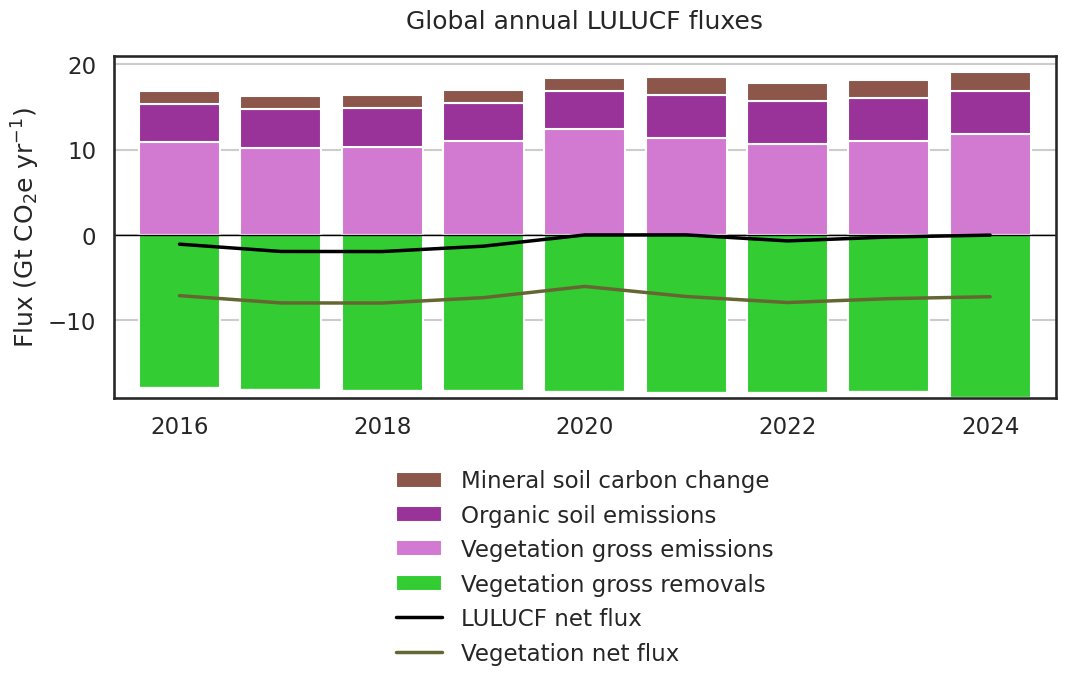

In [28]:
### Global LULUCF components with gross as bars and net veg and LULUCF as lines (single panel)
### Per https://chatgpt.com/g/g-p-69399a7fcc808191b337d3fac695447c-afolu-flux-model/c/69c6d457-96b4-8328-9fca-ff50f8273233

df_fig = LULUCF_graphs_agg.copy()

## Various lists and dictionaries needed to create the figure

# Drop unwanted vegetation-only emissions layers
layers_to_drop = [
    f"veg_{cn.gross_emis_all_C_pools_CO2_only_pattern}",
    f"veg_{cn.gross_emis_all_C_pools_non_CO2_only_pattern}",
]

# Net flux layers to draw as lines instead of bars
net_flux_layers = [
    f"veg_{cn.net_flux_all_C_pools_all_gases_pattern}",
    "LULUCF_net_flux__MgCO2e",
]

# Organic soil layers to combine for graphing
organic_soil_layers = [
    "organic_soil_drainage__all_gases__MgCO2e",
    "organic_soil_extraction__all_gases__MgCO2e",
    "organic_soil_fire__all_gases__MgCO2e",
]

organic_soil_combined_label = "organic_soil__all_gases__MgCO2e"

desired_bar_order = [
    "SOC_change__mineral_soil_extent__0-30cm_MgCO2",
    "organic_soil__all_gases__MgCO2e",
    f"veg_{cn.gross_emis_all_C_pools_all_gases_pattern}",
    f"veg_{cn.gross_removals_all_C_pools_pattern}",
]

desired_line_order = [
    "LULUCF_net_flux__MgCO2e",
    f"veg_{cn.net_flux_all_C_pools_all_gases_pattern}",
]

color_map = {
    "SOC_change__mineral_soil_extent__0-30cm_MgCO2": "#8c564b",  # brown
    "organic_soil__all_gases__MgCO2e": "#993399",                # purple
    f"veg_{cn.gross_emis_all_C_pools_all_gases_pattern}": "#d279d2",  # light purple
    f"veg_{cn.gross_removals_all_C_pools_pattern}": "#33cc33",   # green
    "LULUCF_net_flux__MgCO2e": "#000000",                        # black
    f"veg_{cn.net_flux_all_C_pools_all_gases_pattern}": "#666633",  # green
}

label_map = {
    "SOC_change__mineral_soil_extent__0-30cm_MgCO2":
        "Mineral soil carbon change",
    "organic_soil__all_gases__MgCO2e":
        "Organic soil emissions",
    f"veg_{cn.gross_emis_all_C_pools_all_gases_pattern}":
        "Vegetation gross emissions",
    f"veg_{cn.gross_removals_all_C_pools_pattern}":
        "Vegetation gross removals",
    "LULUCF_net_flux__MgCO2e":
        "LULUCF net flux",
    f"veg_{cn.net_flux_all_C_pools_all_gases_pattern}":
        "Vegetation net flux",
}


## Creates the figure

df_fig = df_fig[~df_fig["analysis_layer"].isin(layers_to_drop)].copy()

# Combine the three organic soil layers into one label
df_fig["analysis_layer"] = df_fig["analysis_layer"].replace(
    {layer: organic_soil_combined_label for layer in organic_soil_layers}
)

# Sum by year and analysis layer
df_ts = (
    df_fig
    .groupby(["year", "analysis_layer"], as_index=False)
    .agg({"flux_Mg_CO2e_yr": "sum"})
)

# Convert to Gt CO2e/yr
df_ts["flux_Gt_CO2e_yr"] = df_ts["flux_Mg_CO2e_yr"] / 1e9

# Pivot to wide form
df_wide = (
    df_ts
    .pivot(index="year", columns="analysis_layer", values="flux_Gt_CO2e_yr")
    .fillna(0)
)

# Apply ordering (keep only columns that exist)
bar_cols = [c for c in desired_bar_order if c in df_wide.columns]
line_cols = [c for c in desired_line_order if c in df_wide.columns]

df_bars = df_wide[bar_cols]
df_lines = df_wide[line_cols]

# Reverse bar order for plotting (top to bottom)
df_bars = df_bars[bar_cols[::-1]]

# Split positive and negative bars so they stack correctly around zero
df_pos = df_bars.clip(lower=0)
df_neg = df_bars.clip(upper=0)

fig, ax = plt.subplots(figsize=(11, 8))

# Positive stacked bars
df_pos.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    width=0.8,
    color=[color_map[c] for c in df_pos.columns]
)

# Negative stacked bars
df_neg.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    width=0.8,
    legend=False,
    color=[color_map[c] for c in df_neg.columns]
)

# Lines
x = np.arange(len(df_wide.index))
for col in line_cols:
    ax.plot(
        x,
        df_lines[col].values,
        linewidth=2.5,
        label=col,
        color=color_map.get(col, "black"),
        zorder=5
    )

# Formatting
ax.axhline(0, color="black", linewidth=1)
ax.grid(visible=True, axis="y")
ax.set_axisbelow(True)

ax.set_xlabel(None)
ax.set_ylabel("Flux (Gt CO$_2$e yr$^{-1}$)")
ax.set_title("Global annual LULUCF fluxes", pad=20)

ax.set_xticks(x[::2])
ax.set_xticklabels(df_wide.index.astype(int)[::2], rotation=0)

# Build legend in desired order
handles, labels = ax.get_legend_handles_labels()
label_to_handle = dict(zip(labels, handles))

ordered_labels = (
    desired_bar_order +
    desired_line_order
)

ordered_labels = [l for l in ordered_labels if l in label_to_handle]

# Map labels to readable names
pretty_labels = [label_map.get(l, l) for l in ordered_labels]

ax.legend(
    [label_to_handle[l] for l in ordered_labels],
    pretty_labels,
    title="",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=1,
    frameon=False
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()
# df_wide

In [111]:
### Summary LULUCF table

#### Vegetation

### Tall vegetation

## Undisturbed tall vegetation
LULUCF_component = "vegetation"
land_state_broad_class = "tree"
land_state_detailed_class = "tree_tree_undisturbed"

# Vegetation->tall veg->undisturbed->net flux CO2
analysis_layer = "veg_net_flux__all_C_pools__CO2_only__MgCO2"
tall_veg_undisturbed_CO2_net_subset = df[
    (df["LULUCF_component"] == LULUCF_component) &
    (df["land_state_broad_class"] == land_state_broad_class) &
    (df["land_state_detailed_class"] == land_state_detailed_class) &
    (df["analysis_layer"] == analysis_layer) 
]
tall_veg_undisturbed_CO2_net = tall_veg_undisturbed_CO2_net_subset["flux_Mg_CO2e_yr"].sum()/10**9
print(f"tall_veg_undisturbed_CO2_net: {tall_veg_undisturbed_CO2_net.round(2)}")

# Vegetation->tall veg->undisturbed->gross emissions CH4
analysis_layer = "veg_gross_emissions__CH4__MgCO2e"
tall_veg_undisturbed_CH4_subset = df[
    (df["LULUCF_component"] == LULUCF_component) &
    (df["land_state_broad_class"] == land_state_broad_class) &
    (df["land_state_detailed_class"] == land_state_detailed_class) &
    (df["analysis_layer"] == analysis_layer) 
]
tall_veg_undisturbed_CH4 = tall_veg_undisturbed_CH4_subset["flux_Mg_CO2e_yr"].sum()/10**9
print(f"tall_veg_undisturbed_CH4: {tall_veg_undisturbed_CH4.round(2)}")

# Vegetation->tall veg->undisturbed->gross emissions N2O
analysis_layer = "veg_gross_emissions__N2O__MgCO2e"
tall_veg_undisturbed_N2O_subset = df[
    (df["LULUCF_component"] == LULUCF_component) &
    (df["land_state_broad_class"] == land_state_broad_class) &
    (df["land_state_detailed_class"] == land_state_detailed_class) &
    (df["analysis_layer"] == analysis_layer) 
]
tall_veg_undisturbed_N2O = tall_veg_undisturbed_N2O_subset["flux_Mg_CO2e_yr"].sum()/10**9
print(f"tall_veg_undisturbed_N2O: {tall_veg_undisturbed_N2O.round(3)}")


## Partially disturbed tall vegetation
LULUCF_component = "vegetation"
land_state_broad_class = "tree"
land_state_detailed_class = "tree_tree_disturbed"

# Vegetation->tall veg->partially disturbed->net flux CO2
analysis_layer = "veg_net_flux__all_C_pools__CO2_only__MgCO2"
tall_veg_disturbed_CO2_net_subset = df[
    (df["LULUCF_component"] == LULUCF_component) &
    (df["land_state_broad_class"] == land_state_broad_class) &
    (df["land_state_detailed_class"] == land_state_detailed_class) &
    (df["analysis_layer"] == analysis_layer) 
]
tall_veg_disturbed_CO2_net = tall_veg_disturbed_CO2_net_subset["flux_Mg_CO2e_yr"].sum()/10**9
print(f"tall_veg_disturbed_CO2_net: {tall_veg_disturbed_CO2_net.round(2)}")

# Vegetation->tall veg->partially disturbed->gross emissions CH4
analysis_layer = "veg_gross_emissions__CH4__MgCO2e"
tall_veg_disturbed_CH4_subset = df[
    (df["LULUCF_component"] == LULUCF_component) &
    (df["land_state_broad_class"] == land_state_broad_class) &
    (df["land_state_detailed_class"] == land_state_detailed_class) &
    (df["analysis_layer"] == analysis_layer) 
]
tall_veg_disturbed_CH4 = tall_veg_disturbed_CH4_subset["flux_Mg_CO2e_yr"].sum()/10**9
print(f"tall_veg_disturbed_CH4: {tall_veg_disturbed_CH4.round(3)}")

# Vegetation->tall veg->partially disturbed->gross emissions N2O
analysis_layer = "veg_gross_emissions__N2O__MgCO2e"
tall_veg_disturbed_N2O_subset = df[
    (df["LULUCF_component"] == LULUCF_component) &
    (df["land_state_broad_class"] == land_state_broad_class) &
    (df["land_state_detailed_class"] == land_state_detailed_class) &
    (df["analysis_layer"] == analysis_layer) 
]
tall_veg_disturbed_N2O = tall_veg_disturbed_N2O_subset["flux_Mg_CO2e_yr"].sum()/10**9
print(f"tall_veg_disturbed_N2O: {tall_veg_disturbed_N2O.round(4)}")


## Lost tall vegetation
LULUCF_component = "vegetation"
land_state_broad_class = "tree"
land_state_detailed_class = "tree_loss"

# Vegetation->tall veg->lost->net flux CO2
analysis_layer = "veg_net_flux__all_C_pools__CO2_only__MgCO2"
tall_veg_loss_CO2_net_subset = df[
    (df["LULUCF_component"] == LULUCF_component) &
    (df["land_state_broad_class"] == land_state_broad_class) &
    (df["land_state_detailed_class"] == land_state_detailed_class) &
    (df["analysis_layer"] == analysis_layer) 
]
tall_veg_loss_CO2_net = tall_veg_loss_CO2_net_subset["flux_Mg_CO2e_yr"].sum()/10**9
print(f"tall_veg_loss_CO2_net: {tall_veg_loss_CO2_net.round(2)}")

# Vegetation->tall veg->lost->gross emissions CH4
analysis_layer = "veg_gross_emissions__CH4__MgCO2e"
tall_veg_loss_CH4_subset = df[
    (df["LULUCF_component"] == LULUCF_component) &
    (df["land_state_broad_class"] == land_state_broad_class) &
    (df["land_state_detailed_class"] == land_state_detailed_class) &
    (df["analysis_layer"] == analysis_layer) 
]
tall_veg_loss_CH4 = tall_veg_loss_CH4_subset["flux_Mg_CO2e_yr"].sum()/10**9
print(f"tall_veg_loss_CH4: {tall_veg_loss_CH4.round(2)}")

# Vegetation->tall veg->lost->gross emissions N2O
analysis_layer = "veg_gross_emissions__N2O__MgCO2e"
tall_veg_loss_N2O_subset = df[
    (df["LULUCF_component"] == LULUCF_component) &
    (df["land_state_broad_class"] == land_state_broad_class) &
    (df["land_state_detailed_class"] == land_state_detailed_class) &
    (df["analysis_layer"] == analysis_layer) 
]
tall_veg_loss_N2O = tall_veg_loss_N2O_subset["flux_Mg_CO2e_yr"].sum()/10**9
print(f"tall_veg_loss_N2O: {tall_veg_loss_N2O.round(3)}")


## Gained tall vegetation
LULUCF_component = "vegetation"
land_state_broad_class = "tree"
land_state_detailed_class = "tree_gain"

# Vegetation->tall veg->gained->net flux CO2
analysis_layer = "veg_net_flux__all_C_pools__CO2_only__MgCO2"
tall_veg_gain_CO2_net_subset = df[
    (df["LULUCF_component"] == LULUCF_component) &
    (df["land_state_broad_class"] == land_state_broad_class) &
    (df["land_state_detailed_class"] == land_state_detailed_class) &
    (df["analysis_layer"] == analysis_layer) 
]
tall_veg_gain_CO2_net = tall_veg_gain_CO2_net_subset["flux_Mg_CO2e_yr"].sum()/10**9
print(f"tall_veg_gain_CO2_net: {tall_veg_gain_CO2_net.round(2)}")

# Vegetation->tall veg->gained->gross emissions CH4
analysis_layer = "veg_gross_emissions__CH4__MgCO2e"
tall_veg_gain_CH4_subset = df[
    (df["LULUCF_component"] == LULUCF_component) &
    (df["land_state_broad_class"] == land_state_broad_class) &
    (df["land_state_detailed_class"] == land_state_detailed_class) &
    (df["analysis_layer"] == analysis_layer) 
]
tall_veg_gain_CH4 = tall_veg_gain_CH4_subset["flux_Mg_CO2e_yr"].sum()/10**9
print(f"tall_veg_gain_CH4: {tall_veg_gain_CH4.round(2)}")

# Vegetation->tall veg->gained->gross emissions N2O
analysis_layer = "veg_gross_emissions__N2O__MgCO2e"
tall_veg_gain_N2O_subset = df[
    (df["LULUCF_component"] == LULUCF_component) &
    (df["land_state_broad_class"] == land_state_broad_class) &
    (df["land_state_detailed_class"] == land_state_detailed_class) &
    (df["analysis_layer"] == analysis_layer) 
]
tall_veg_gain_N2O = tall_veg_gain_N2O_subset["flux_Mg_CO2e_yr"].sum()/10**9
print(f"tall_veg_gain_N2O: {tall_veg_gain_N2O.round(3)}")


### Non-tall vegetation (short veg and cropland)

## Non-tall vegetation (all classes)->net flux CO2
LULUCF_component = "vegetation"
land_state_broad_class = "tree"

# Vegetation->tall veg->gained->net flux CO2
analysis_layer = "veg_net_flux__all_C_pools__CO2_only__MgCO2"
non_tall_veg_CO2_net_subset = df[
    (df["LULUCF_component"] == LULUCF_component) &
    (df["land_state_broad_class"] != land_state_broad_class) &
    (df["analysis_layer"] == analysis_layer) 
]
non_tall_veg_CO2_net = non_tall_veg_CO2_net_subset["flux_Mg_CO2e_yr"].sum()/10**9
print(f"non_tall_veg_CO2_net: {non_tall_veg_CO2_net.round(3)}")

# Vegetation->tall veg->gained->gross_emissions CH4
analysis_layer = "veg_gross_emissions__CH4__MgCO2e"
non_tall_veg_CH4_net_subset = df[
    (df["LULUCF_component"] == LULUCF_component) &
    (df["land_state_broad_class"] != land_state_broad_class) &
    (df["analysis_layer"] == analysis_layer) 
]
non_tall_veg_CH4_net = non_tall_veg_CH4_net_subset["flux_Mg_CO2e_yr"].sum()/10**9
print(f"non_tall_veg_CH4_net: {non_tall_veg_CH4_net.round(3)}")

# Vegetation->tall veg->gained->gross_emissions N2O
analysis_layer = "veg_gross_emissions__N2O__MgCO2e"
non_tall_veg_N2O_net_subset = df[
    (df["LULUCF_component"] == LULUCF_component) &
    (df["land_state_broad_class"] != land_state_broad_class) &
    (df["analysis_layer"] == analysis_layer) 
]
non_tall_veg_N2O_net = non_tall_veg_N2O_net_subset["flux_Mg_CO2e_yr"].sum()/10**9
print(f"non_tall_veg_N2O_net: {non_tall_veg_N2O_net.round(4)}")

tall_veg_undisturbed_CO2_net: -15.57
tall_veg_undisturbed_CH4: 0.17
tall_veg_undisturbed_N2O: 0.051
tall_veg_disturbed_CO2_net: 1.32
tall_veg_disturbed_CH4: 0.006
tall_veg_disturbed_N2O: 0.0023
tall_veg_loss_CO2_net: 6.75
tall_veg_loss_CH4: 0.04
tall_veg_loss_N2O: 0.017
tall_veg_gain_CO2_net: -0.23
tall_veg_gain_CH4: 0.0
tall_veg_gain_N2O: 0.0
non_tall_veg_CO2_net: -0.024
non_tall_veg_CH4_net: 0.042
non_tall_veg_N2O_net: 0.0298


In [183]:
### Summary LULUCF table
### https://chatgpt.com/g/g-p-69399a7fcc808191b337d3fac695447c/c/69cd271d-3714-8325-b311-2ccf7a07e632

df = LULUCF_summary_table.copy()

# -------------------------
# 1. Classify gas for each row
# -------------------------
def get_gas(layer):
    layer = str(layer)

    if "__CH4__" in layer:
        return "CH4_Mg_CO2e_yr"
    elif "__N2O__" in layer:
        return "N2O_Mg_CO2e_yr"
    elif "CO2_only" in layer or "mineral_soil" in layer:
        return "CO2_Mg_CO2e_yr"
    elif "all_gases" in layer:
        return "All gases_Mg_CO2e_yr"
    else:
        return None

df["gas"] = df["analysis_layer"].apply(get_gas)
df

# -------------------------
# 2. Split vegetation vs soil because they need to be handled separately
# -------------------------
veg = df[df["LULUCF_component"] == "vegetation"].copy()
soil = df[df["LULUCF_component"] != "vegetation"].copy()

# -------------------------
# 3. Vegetation: pivot WITHOUT analysis_layer in the index.
#    This is what consolidates CO2/CH4/N2O onto one row.
# -------------------------
veg_wide = (
    veg.pivot_table(
        index=[
            "land_state_broad_class",
            "land_state_detailed_class",
            "tall_veg_type",
            "LULUCF_component",
        ],
        columns="gas",
        values="flux_Mg_CO2e_yr",
        aggfunc="sum",
        fill_value=0,
    )
    .reset_index()
)
veg_wide.columns.name = None  # Drops gas from top left of table (label for column index)

# Populates columns with 0 if they don't exist
for col in ["CO2_Mg_CO2e_yr", "CH4_Mg_CO2e_yr", "N2O_Mg_CO2e_yr", "All gases_Mg_CO2e_yr"]:
    if col not in veg_wide.columns:
        veg_wide[col] = 0

# Create vegetation total for all gases if there isn't already a total for all gases
veg_wide["All gases_Mg_CO2e_yr"] = np.where(
    veg_wide["All gases_Mg_CO2e_yr"].notna() & (veg_wide["All gases_Mg_CO2e_yr"] != 0),
    veg_wide["All gases_Mg_CO2e_yr"],
    veg_wide["CO2_Mg_CO2e_yr"] + veg_wide["CH4_Mg_CO2e_yr"] + veg_wide["N2O_Mg_CO2e_yr"]
)

# Rename analysis layer for consolidated vegetation rows (because it's no longer gas-specific)
veg_wide["analysis_layer"] = "veg_net_flux__MgCO2e"

# Reorder columns
veg_wide = veg_wide[
    [
        "analysis_layer",
        "land_state_broad_class",
        "land_state_detailed_class",
        "tall_veg_type",
        "LULUCF_component",
        "CO2_Mg_CO2e_yr",
        "CH4_Mg_CO2e_yr",
        "N2O_Mg_CO2e_yr",
        "All gases_Mg_CO2e_yr",
    ]
]
# veg_wide

# -------------------------
# 4. Soil: keep rows as all-gases-only. 
#    Don't use vegetation-specific contextual layers. 
# -------------------------
soil_wide = (
    soil.pivot_table(
        index=[
            "analysis_layer",
            "LULUCF_component",
        ],
        columns="gas",
        values="flux_Mg_CO2e_yr",
        aggfunc="sum",
        fill_value=0,
    )
    .reset_index()
)
soil_wide.columns.name = None  # Drops gas from top left of table (label for column index)

# Add vegetation columns back to soil table so the tables can be combined
soil_wide["land_state_broad_class"] = "NA"
soil_wide["land_state_detailed_class"] = "NA"
soil_wide["tall_veg_type"] = "NA"

# Populates columns with 0 if they don't exist
for col in ["CO2_Mg_CO2e_yr", "CH4_Mg_CO2e_yr", "N2O_Mg_CO2e_yr", "All gases_Mg_CO2e_yr"]:
    if col not in soil_wide.columns:
        soil_wide[col] = 0

# Create soil total for all gases if there isn't already a total for all gases
soil_wide["All gases_Mg_CO2e_yr"] = np.where(
    soil_wide["All gases_Mg_CO2e_yr"].notna() & (soil_wide["All gases_Mg_CO2e_yr"] != 0),
    soil_wide["All gases_Mg_CO2e_yr"],
    soil_wide["CO2_Mg_CO2e_yr"] + soil_wide["CH4_Mg_CO2e_yr"] + soil_wide["N2O_Mg_CO2e_yr"]
)

# Same calumn order for soil columns
soil_wide = soil_wide[
    [
        "analysis_layer",
        "land_state_broad_class",
        "land_state_detailed_class",
        "tall_veg_type",
        "LULUCF_component",
        "CO2_Mg_CO2e_yr",
        "CH4_Mg_CO2e_yr",
        "N2O_Mg_CO2e_yr",
        "All gases_Mg_CO2e_yr",
    ]
]
# soil_wide

# -------------------------
# 5. Combine veg and soil
# -------------------------
df_wide = pd.concat([veg_wide, soil_wide], ignore_index=True)
df_wide

# -------------------------
# 6. Creates table entries 
# -------------------------

gas_cols = ["CO2_Mg_CO2e_yr", "CH4_Mg_CO2e_yr", "N2O_Mg_CO2e_yr", "All gases_Mg_CO2e_yr"]

def get_sum(df, mask, section, subsection, category):
    vals = df.loc[mask, gas_cols].sum().round(0)

    return {
        "Section": section,
        "Subsection": subsection,
        "Category": category,
        **vals.to_dict()
    }

rows = []

# -------------------------
# Vegetation — Tall vegetation
# -------------------------
rows.append(get_sum(
    df_wide,
    (df_wide["LULUCF_component"] == "vegetation") &
    (df_wide["land_state_broad_class"] == "tree") &
    (df_wide["land_state_detailed_class"] == "tree_gain"),
    "Vegetation", "Tall vegetation", "New tree cover"
))
rows.append(get_sum(
    df_wide,
    (df_wide["LULUCF_component"] == "vegetation") &
    (df_wide["land_state_broad_class"] == "tree") &
    (df_wide["land_state_detailed_class"] == "tree_tree_undisturbed"),
    "Vegetation", "Tall vegetation", "Undisturbed tree cover (including fires)"
))
rows.append(get_sum(
    df_wide,
    (df_wide["LULUCF_component"] == "vegetation") &
    (df_wide["land_state_broad_class"] == "tree") &
    (df_wide["land_state_detailed_class"] == "tree_tree_disturbed"),
    "Vegetation", "Tall vegetation", "Partially disturbed tree cover"
))
rows.append(get_sum(
    df_wide,
    (df_wide["LULUCF_component"] == "vegetation") &
    (df_wide["land_state_broad_class"] == "tree") &
    (df_wide["land_state_detailed_class"] == "tree_loss"),
    "Vegetation", "Tall vegetation", "Tree cover loss"
))
# Total tall vegetation
rows.append(get_sum(
    df_wide,
    (df_wide["LULUCF_component"] == "vegetation") &
    (df_wide["land_state_broad_class"] == "tree"),
    "Vegetation", "Tall vegetation", "Total"
))

# -------------------------
# Vegetation — Non-tall
# -------------------------
rows.append(get_sum(
    df_wide,
    (df_wide["LULUCF_component"] == "vegetation") &
    (df_wide["tall_veg_type"] == "non_tall_vegetation"),
    "Vegetation", "Non-tall vegetation", "All classes"
))

# -------------------------
# Vegetation — Total
# -------------------------
rows.append(get_sum(
    df_wide,
    df_wide["LULUCF_component"] == "vegetation",
    "Vegetation", "All vegetation", "Total"
))

# -------------------------
# Soil — Organic
# -------------------------
rows.append(get_sum(
    df_wide,
    df_wide["analysis_layer"].str.contains("organic_soil_fire"),
    "Soil", "Organic soil", "Fire"
))

rows.append(get_sum(
    df_wide,
    df_wide["analysis_layer"].str.contains("organic_soil_extraction"),
    "Soil", "Organic soil", "Extraction"
))

rows.append(get_sum(
    df_wide,
    df_wide["analysis_layer"].str.contains("organic_soil_drainage"),
    "Soil", "Organic soil", "Drainage"
))

# Total organic soil
rows.append(get_sum(
    df_wide,
    df_wide["LULUCF_component"] == "organic_soil",
    "Soil", "Organic soil", "Total"
))

# -------------------------
# Soil — Mineral
# -------------------------
rows.append(get_sum(
    df_wide,
    df_wide["LULUCF_component"] == "mineral_soil",
    "Soil", "Mineral soil", "All classes"
))

# -------------------------
# Soil — Total
# -------------------------
rows.append(get_sum(
    df_wide,
    df_wide["LULUCF_component"].isin(["organic_soil", "mineral_soil"]),
    "Soil", "All soil", "Total"
))

# -------------------------
# LULUCF — Total
# -------------------------
rows.append(get_sum(
    df_wide,
    pd.Series([True] * len(df_wide)),
    "LULUCF", "All components", "Total"
))

# -------------------------
# 6. Creates final table 
# -------------------------

summary = pd.DataFrame(rows)

# Convert Mg → Gt
summary[gas_cols] = summary[gas_cols] / 1e9

# Rename column units
summary = summary.rename(columns={
    "CO2_Mg_CO2e_yr": "CO2_Gt_CO2e_yr",
    "CH4_Mg_CO2e_yr": "CH4_Gt_CO2e_yr",
    "N2O_Mg_CO2e_yr": "N2O_Gt_CO2e_yr",
    "All gases_Mg_CO2e_yr": "All_gases_Gt_CO2e_yr",
})

summary = summary.round(3).style.hide(axis="index")
summary

Section,Subsection,Category,CO2_Gt_CO2e_yr,CH4_Gt_CO2e_yr,N2O_Gt_CO2e_yr,All_gases_Gt_CO2e_yr
Vegetation,Tall vegetation,New tree cover,-0.231000,0.000000,0.000000,-0.231000
Vegetation,Tall vegetation,Undisturbed tree cover (including fires),-15.573000,0.166000,0.051000,-15.356000
Vegetation,Tall vegetation,Partially disturbed tree cover,1.324000,0.006000,0.002000,1.332000
Vegetation,Tall vegetation,Tree cover loss,6.747000,0.040000,0.017000,6.804000
Vegetation,Tall vegetation,Total,-7.734000,0.213000,0.070000,-7.451000
Vegetation,Non-tall vegetation,All classes,-0.024000,0.042000,0.030000,0.048000
Vegetation,All vegetation,Total,-7.758000,0.255000,0.100000,-7.403000
Soil,Organic soil,Fire,0.000000,0.000000,0.000000,1.023000
Soil,Organic soil,Extraction,0.000000,0.000000,0.000000,0.039000
Soil,Organic soil,Drainage,0.000000,0.000000,0.000000,3.714000


In [98]:
### Summary LULUCF table
### Per https://chatgpt.com/g/g-p-69399a7fcc808191b337d3fac695447c/c/69cd271d-3714-8325-b311-2ccf7a07e632

df = LULUCF_summary_table.copy()

# --------------------------------------------------
# Classify analysis_layer into CO2 / CH4 / N2O / All gases
# --------------------------------------------------
def classify_gas(layer):
    layer = str(layer)

    if "all_gases" in layer:
        return "All gases"
    elif "CH4" in layer:
        return "CH4"
    elif "N2O" in layer:
        return "N2O"
    elif ("CO2_only" in layer) or ("MgCO2" in layer):
        return "CO2"
    else:
        return np.nan

# --------------------------------------------------
# Row definitions
# --------------------------------------------------
ROW_SPECS = [
    # ---------------- Vegetation ----------------
    {
        "Section": "Vegetation",
        "Subsection": "Tall vegetation",
        "Category": "Undisturbed tree cover (including fires)",
        "filter": lambda x: (
            (x["LULUCF_component"] == "vegetation") &
            (x["land_state_broad_class"] == "tree") &
            (x["land_state_detailed_class"] == "tree_tree_undisturbed") &
            (x["analysis_layer"] == "veg_net_flux__all_C_pools__CO2_only__MgCO2")
        )
    },
    {
        "Section": "Vegetation",
        "Subsection": "Tall vegetation",
        "Category": "Partially disturbed tree cover",
        "filter": lambda x: (
            (x["LULUCF_component"] == "vegetation") &
            (x["land_state_broad_class"] == "tree") &
            (x["land_state_detailed_class"] == "tree_tree_disturbed") & 
            (x["analysis_layer"] == "veg_net_flux__all_C_pools__CO2_only__MgCO2")
        )
    },
    {
        "Section": "Vegetation",
        "Subsection": "Tall vegetation",
        "Category": "New tree cover",
        "filter": lambda x: (
            (x["LULUCF_component"] == "vegetation") &
            (x["land_state_broad_class"] == "tree") &
            (x["land_state_detailed_class"] == "tree_gain") &
            (x["analysis_layer"] == "veg_net_flux__all_C_pools__CO2_only__MgCO2")
        )
    },
    {
        "Section": "Vegetation",
        "Subsection": "Tall vegetation",
        "Category": "Tree cover loss",
        "filter": lambda x: (
            (x["LULUCF_component"] == "vegetation") &
            (x["land_state_broad_class"] == "tree") &
            (x["land_state_detailed_class"] == "tree_loss") &
            (x["analysis_layer"] == "veg_net_flux__all_C_pools__CO2_only__MgCO2")
        )
    },
    {
        "Section": "Vegetation",
        "Subsection": "Non-tall vegetation",
        "Category": "All classes",
        "filter": lambda x: (
            (x["LULUCF_component"] == "vegetation") &
            (x["land_state_broad_class"] != "tree") &
            (x["analysis_layer"] == "veg_net_flux__all_C_pools__CO2_only__MgCO2")
        )
    },

    # ---------------- Soil ----------------
    {
        "Section": "Soil",
        "Subsection": "Organic soil",
        "Category": "Fire",
        "filter": lambda x: x["analysis_layer"].str.contains("organic_soil.*fire", case=False, na=False)
    },
    {
        "Section": "Soil",
        "Subsection": "Organic soil",
        "Category": "Extraction",
        "filter": lambda x: x["analysis_layer"].str.contains("organic_soil.*extraction", case=False, na=False)
    },
    {
        "Section": "Soil",
        "Subsection": "Organic soil",
        "Category": "Drainage",
        "filter": lambda x: x["analysis_layer"].str.contains("organic_soil.*drainage", case=False, na=False)
    },
    {
        "Section": "Soil",
        "Subsection": "Mineral soil",
        "Category": "All classes",
        "filter": lambda x: x["analysis_layer"].str.contains("SOC_change", case=False, na=False)
    },
]

# --------------------------------------------------
# Helper to calculate one row
# --------------------------------------------------
def calc_row(df, spec):
    sub = df.loc[spec["filter"](df)].copy()

    sums = sub.groupby("gas", as_index=False)["flux_Mg_CO2e_yr"].sum()

    gas_map = dict(zip(sums["gas"], sums["flux_Mg_CO2e_yr"]))

    CO2 = gas_map.get("CO2", 0.0)
    CH4 = gas_map.get("CH4", 0.0)
    N2O = gas_map.get("N2O", 0.0)

    # Mg -> Gt
    CO2 /= 1e9
    CH4 /= 1e9
    N2O /= 1e9

    return {
        "Section": spec["Section"],
        "Subsection": spec["Subsection"],
        "Category": spec["Category"],
        "CO2": CO2,
        "CH4": CH4,
        "N2O": N2O
    }

df["gas"] = df["analysis_layer"].apply(classify_gas)
df = df[df["gas"].notna()].copy()
df


# --------------------------------------------------
# Build non-total rows
# --------------------------------------------------
rows = [calc_row(df, spec) for spec in ROW_SPECS]
rows
table = pd.DataFrame(rows)
table

,Section,Subsection,Category,CO2,CH4,N2O
0,Vegetation,Tall vegetation,Undisturbed tree cover (including fires),-15.573474,0.0,0.0
1,Vegetation,Tall vegetation,Partially disturbed tree cover,1.324191,0.0,0.0
2,Vegetation,Tall vegetation,New tree cover,-0.231339,0.0,0.0
3,Vegetation,Tall vegetation,Tree cover loss,6.747048,0.0,0.0
4,Vegetation,Non-tall vegetation,All classes,-0.024027,0.0,0.0
5,Soil,Organic soil,Fire,0.000000,0.0,0.0
6,Soil,Organic soil,Extraction,0.000000,0.0,0.0
7,Soil,Organic soil,Drainage,0.000000,0.0,0.0
8,Soil,Mineral soil,All classes,3.641341,0.0,0.0


In [ ]:
# # --------------------------------------------------
# # Add subtotal rows
# # --------------------------------------------------
# subtotal_rows = []

# # Vegetation > Tall vegetation > Total
# tmp = table[
#     (table["Section"] == "Vegetation") &
#     (table["Subsection"] == "Tall vegetation")
# ]
# subtotal_rows.append({
#     "Section": "Vegetation",
#     "Subsection": "Tall vegetation",
#     "Category": "Total",
#     "CO2": tmp["CO2"].sum(),
#     "Non-CO2": tmp["Non-CO2"].sum(),
#     "All gases": tmp["All gases"].sum(),
# })

# # Vegetation > All vegetation > Total
# tmp = table[
#     (table["Section"] == "Vegetation") &
#     (table["Subsection"].isin(["Tall vegetation", "Non-tall vegetation"]))
# ]
# subtotal_rows.append({
#     "Section": "Vegetation",
#     "Subsection": "All vegetation",
#     "Category": "Total",
#     "CO2": tmp["CO2"].sum(),
#     "Non-CO2": tmp["Non-CO2"].sum(),
#     "All gases": tmp["All gases"].sum(),
# })

# # Soil > Organic soil > Total
# tmp = table[
#     (table["Section"] == "Soil") &
#     (table["Subsection"] == "Organic soil")
# ]
# subtotal_rows.append({
#     "Section": "Soil",
#     "Subsection": "Organic soil",
#     "Category": "Total",
#     "CO2": tmp["CO2"].sum(),
#     "Non-CO2": tmp["Non-CO2"].sum(),
#     "All gases": tmp["All gases"].sum(),
# })

# # Soil > All soil > Total
# tmp = table[
#     (table["Section"] == "Soil") &
#     (table["Subsection"].isin(["Organic soil", "Mineral soil"]))
# ]
# subtotal_rows.append({
#     "Section": "Soil",
#     "Subsection": "All soil",
#     "Category": "Total",
#     "CO2": tmp["CO2"].sum(),
#     "Non-CO2": tmp["Non-CO2"].sum(),
#     "All gases": tmp["All gases"].sum(),
# })

# table = pd.concat([table, pd.DataFrame(subtotal_rows)], ignore_index=True)
# # table

# # --------------------------------------------------
# # Apply exact row order
# # --------------------------------------------------
# row_order = [
#     ("Vegetation", "Tall vegetation", "Undisturbed tree cover (including fires)"),
#     ("Vegetation", "Tall vegetation", "Partially disturbed tree cover"),
#     ("Vegetation", "Tall vegetation", "New tree cover"),
#     ("Vegetation", "Tall vegetation", "Tree cover loss"),
#     ("Vegetation", "Tall vegetation", "Total"),
#     ("Vegetation", "Non-tall vegetation", "All classes"),
#     ("Vegetation", "All vegetation", "Total"),
#     ("Soil", "Organic soil", "Fire"),
#     ("Soil", "Organic soil", "Extraction"),
#     ("Soil", "Organic soil", "Drainage"),
#     ("Soil", "Organic soil", "Total"),
#     ("Soil", "Mineral soil", "All classes"),
#     ("Soil", "All soil", "Total"),
#     ("LULUCF", "All components", "Total"),
# ]

# order_df = pd.DataFrame(row_order, columns=["Section", "Subsection", "Category"])
# table = order_df.merge(table, on=["Section", "Subsection", "Category"], how="left")

# # --------------------------------------------------
# # Fill blanks and round
# # --------------------------------------------------
# for col in ["CO2", "Non-CO2", "All gases"]:
#     table[col] = table[col].fillna(0)

# table[["CO2", "Non-CO2", "All gases"]] = table[["CO2", "Non-CO2", "All gases"]].round(2)

# table